# Сборный Проект — 2. HR-аналитика

**Описание проекта**

Позади много уроков и заданий, и закрепить свои знания, как обычно, вы сможете в самостоятельном проекте. Это непростой проект, в котором от вас потребуется больше самостоятельности. Этапы работы описаны кратко, и вам понадобится декомпозировать задачи, то есть разделить их на более мелкие. Опирайтесь на знания об этапах анализа данных и машинного обучения из прошлых курсов.

Перейдём к задаче. HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён.

Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. 

У вас будет несколько задач. Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 

Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.

Ваша вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

**Задача 1: предсказание уровня удовлетворённости сотрудника**

Для этой задачи заказчик предоставил данные с признаками:
- `id` — уникальный идентификатор сотрудника;
- `dept` — отдел, в котором работает сотрудник;
- `level` — уровень занимаемой должности;
- `workload` — уровень загруженности сотрудника;
- `employment_years` — длительность работы в компании (в годах);
- `last_year_promo` — показывает, было ли повышение за последний год;
- `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год;
- `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель;
- `salary` — ежемесячная зарплата сотрудника;
- `job_satisfaction_rate` — уровень удовлетворённости сотрудника работой в компании, целевой признак.

**Задача 2: предсказание увольнения сотрудника из компании**

Для этой задачи вы можете использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.

**Импортируем и установим все необходимые библиотеки для исследования:**

(некоторые библиотеки могут установиться не с первого раза)

In [7]:
!pip install numpy==1.26.4 

In [8]:
!pip install matplotlib==3.5.0

In [9]:
!pip install phik

In [10]:
!pip install -q --upgrade scikit-learn

In [11]:
!pip install shap 

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import phik
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, 
                              RandomForestClassifier, GradientBoostingClassifier)
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import shap
from sklearn.metrics import make_scorer

RANDOM_STATE = 42

## Задача 1: Предсказание уровня удовлетворённости сотрудника

### Загрузка данных

**Загрузим данные**

Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы.

In [13]:
train_select = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
X_test = pd.read_csv('/datasets/test_features.csv')
y_test = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

Выведем первые строки датафреймов, чтобы проверить, правильно ли считались данные:

In [14]:
train_select.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [15]:
X_test.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [16]:
y_test.head()

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


Можно говорить о том, что CSV-файлы считались правильно, и с такими датафреймами уже можно работать.

### Предобработка данных

Изучим данные и сделаем выводы. 


#### Изучим общую информацию о датафреймах

Теперь для лучшего понимания данных, хранящихся в датафреймах, выведем информацию о них методом `.info()`:

In [17]:
train_select.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


In [18]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [19]:
y_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


Проанализировав информацию о датафреймах, можно говорить, что все типы данных **соответствуют** в действительности самим данным - то есть необходимости изменять их тип - **нет**. Однако было замечено, что некоторые строки в датафреймах нулевые. Также стоит отметить, что все столбцы имеют "*стандартизированный вид*", то есть: латинский алфавит, прописные буквы, "змеевидная запись"(через нижнее подчеркивание).

#### Проверим наличие пропусков в данных

Воспользуемся методом `.isna()` для поиска пропусков во всех датафреймах и просуммируем их методом `.sum()`:

In [20]:
train_select.isna().sum()

id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

In [21]:
X_test.isna().sum()

id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

In [22]:
y_test.isna().sum()

id                       0
job_satisfaction_rate    0
dtype: int64

Из результатов вывода видно, что пропущенные значения есть в датафреймах `train_select` и `X_test`, но их очень малое количество.

Создадим пайплайн для заполнения пропусков:

In [23]:
fill_data_pipe = Pipeline(
    [
        ('simpleImputer_fill', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ]
)

Теперь заполним пропущенные значения с помощью пайплайна:

In [24]:
# столбцы с пропусками
filling_cols = ['dept', 'level', 'workload']
# заполнение пропусков
train_select[filling_cols] = fill_data_pipe.fit_transform(train_select[filling_cols])
X_test[filling_cols] = fill_data_pipe.transform(X_test[filling_cols])

Повторно выведем число пропусков в столбцах датафреймов:

In [25]:
train_select.isna().sum()

id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

In [26]:
X_test.isna().sum()

id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

Как видим из повторного вывода суммы пропусков в столбцах `'dept'`, `'level'` не осталось пропусков.

#### Проверим данные на наличие дубликатов

После проверки датафреймов на наличие пропусков, проверим их на наличие дубликатов:

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество:

In [27]:
train_select.duplicated().sum()

0

In [28]:
X_test.duplicated().sum()

0

In [29]:
y_test.duplicated().sum()

0

В результате наблюдаем, что *явных* дубликатов нет.

Теперь проверим данные на наличие *неявных* дубликатов, которые также могут встретиться. Для этого необходимо будет проверить все категориальные столбцы с данными на уникальность методом `.unique()`. Так как столбцов с данными много, то для оптимизации работы напишем функцию `unique_search()`: в неё будем передавать датафрейм, его имя(строкой) и названия столбцов категориальных переменных:

In [30]:
def unique_search(dataframe, df_name , data_list):
    for i in data_list:
        print('\nДатафрейм ' + df_name + ', столбец <' + i + '>:\n')
        print(dataframe[i].unique())

Применим функцию `unique_search()` к датафреймам `train_select`, `X_test` и после проанализируем результаты вывода(датафрейм `y_test` не содержит категориальных переменных, поэтому его рассматривать не будем):

In [31]:
unique_search(train_select, 'train_select', train_select.drop(columns = train_select.describe().columns).columns)


Датафрейм train_select, столбец <dept>:

['sales' 'hr' 'technology' 'purchasing' 'marketing']

Датафрейм train_select, столбец <level>:

['junior' 'middle' 'sinior']

Датафрейм train_select, столбец <workload>:

['medium' 'high' 'low']

Датафрейм train_select, столбец <last_year_promo>:

['no' 'yes']

Датафрейм train_select, столбец <last_year_violations>:

['no' 'yes']


Из результатов проверки на уникальность видно, что есть данные в столбцах, которые написаны либо неправильно, либо обозначают одно и тоже. 


Заменим методом `.replace()` неправильные названия в ячейках столбцов датафрейма:

In [32]:
train_select['level'] = train_select['level'].replace('sinior','senior')

Повторно вызовем для проверки функцию `unique_search()` к датафреймам, чтобы убедиться в изменении нами данных:

In [33]:
unique_search(train_select, 'train_select', train_select.drop(columns = train_select.describe().columns).columns)


Датафрейм train_select, столбец <dept>:

['sales' 'hr' 'technology' 'purchasing' 'marketing']

Датафрейм train_select, столбец <level>:

['junior' 'middle' 'senior']

Датафрейм train_select, столбец <workload>:

['medium' 'high' 'low']

Датафрейм train_select, столбец <last_year_promo>:

['no' 'yes']

Датафрейм train_select, столбец <last_year_violations>:

['no' 'yes']


Видно, что изменения были успешно выполнены.

**Промежуточный вывод:**

В результате предобработки данных были выполнены следующие шаги:
- изучили основную информацию о датафреймах
- определили, что типы данных соответствуют действительности
- определили, что названия столбцов имеют правильную запись
- обработали пропуски в столбцах датафреймов с помощью созданного пайплайна
- проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
- преобразовали неявные дубликаты там, где это было возможно

### Исследовательский анализ данных

Исследуем признаки и сделаем выводы о том, как их нужно подготовить.

**Проведём статистический анализ всех признаков**

Как ранее можно было заметить в датафреймах присутствуют как категориальные, так и количественные переменные. В связи с эти требуется отдельная обработка для данных каждого типа.

#### Рассмотрим количественные переменные

Воспользуемся методом `.describe()` для того, что вывести все признаки количественных переменных в датафреймах.

In [34]:
train_select.drop(columns='id').describe()

,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,3.718500,3.476500,33926.700000,0.533995
std,2.542513,1.008812,14900.703838,0.225327
min,1.000000,1.000000,12000.000000,0.030000
25%,2.000000,3.000000,22800.000000,0.360000
50%,3.000000,4.000000,30000.000000,0.560000
75%,6.000000,4.000000,43200.000000,0.710000
max,10.000000,5.000000,98400.000000,1.000000


In [35]:
X_test.drop(columns='id').describe()

,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000
mean,3.666500,3.526500,34066.800000
std,2.537222,0.996892,15398.436729
min,1.000000,1.000000,12000.000000
25%,1.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,96000.000000


In [36]:
y_test.drop(columns='id').describe()

,job_satisfaction_rate
count,2000.00000
mean,0.54878
std,0.22011
min,0.03000
25%,0.38000
50%,0.58000
75%,0.72000
max,1.00000


Из представленных описательных характеристик можно говорить о том, что данные, в принципе, довольно хорошо представлены. Проверим данные на наличие выбросов построением диаграммы размаха("ящика с усами") и сделаем выводы о данных.

Для упрощения работы создадим функцию `counting_param()`, которая будет визуализировать гистограмму и "ящик с усами" в зависимости от передаваемых параметров:

In [37]:
# функция визуализации графиков
# в функцию передаётся: датафрейм, список столбцов датафрейма, название оси Х, название оси У
def counting_param(dataframe, columns_list, measure_x, measure_y):
    for i,j in zip(columns_list, measure_x):
        plt.figure(figsize=(20, 15))
        # Вывод графиков
        plt.subplot(2, 2, 1)
        # Шаблон для построения гистограммы
        dataframe[i].plot(kind='hist', bins=75, grid=True)
        plt.xlabel(j)
        plt.ylabel(measure_y)
        plt.subplot(2, 2, 2)
        # Шаблон для построения "ящика с усами"
        dataframe.boxplot(column=[i])
        plt.xticks([])
        plt.ylabel(j)

In [38]:
# функция построения столбчатых диаграмм
# в функцию передаётся: датафрейм, список столбцов датафрейма, название оси Х, название оси У
def bar_diagram(dataframe, columns_list, measure_x, measure_y):
    for i,j in zip(columns_list, measure_x):
        plt.figure(figsize=(20, 15))
        # Вывод графиков
        plt.subplot(2, 2, 1)
        # Шаблон для построения гистограммы
        dataframe[i].value_counts().plot(kind='bar',  grid=True)
        plt.xlabel(j)
        plt.xticks(rotation=0)
        plt.ylabel(measure_y)
        plt.subplot(2, 2, 2)
        # Шаблон для построения "ящика с усами"
        dataframe.boxplot(column=[i])
        plt.xticks([])
        plt.ylabel(j)

Теперь вызовем эти функции к определенному столбцу датафрейма `train_select`, содержащим количественные переменные:

In [39]:
train_select_title_list = (['Зарплата(д.е.)', 'Уровень удовлетворённости сотрудника'])
bar_title_list = (['Длительность работы(в годах)', 'Оценка качества работы сотрудника от руководителя'])

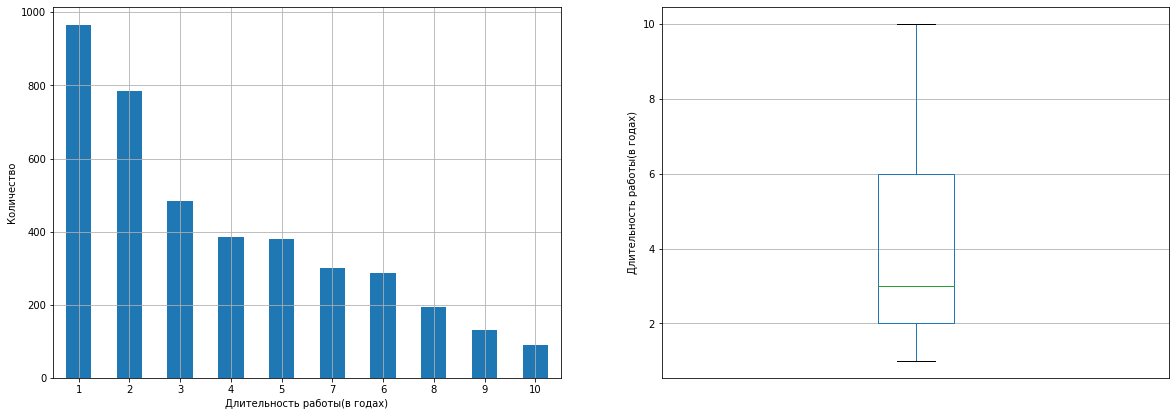

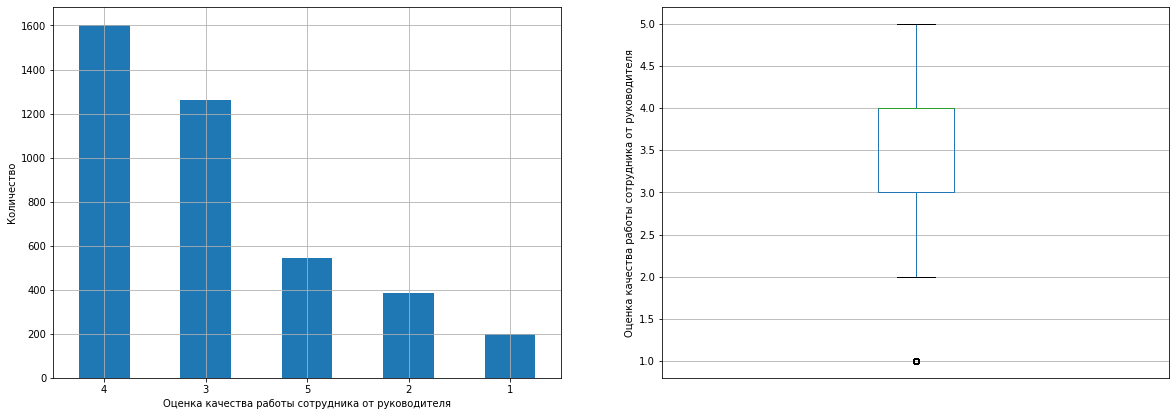

In [40]:
bar_diagram(train_select, ['employment_years', 'supervisor_evaluation'], bar_title_list,'Количество')

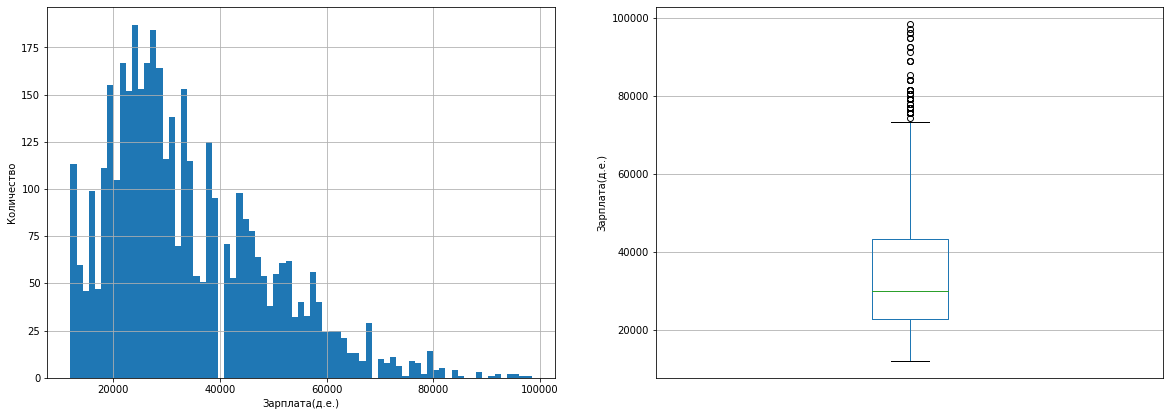

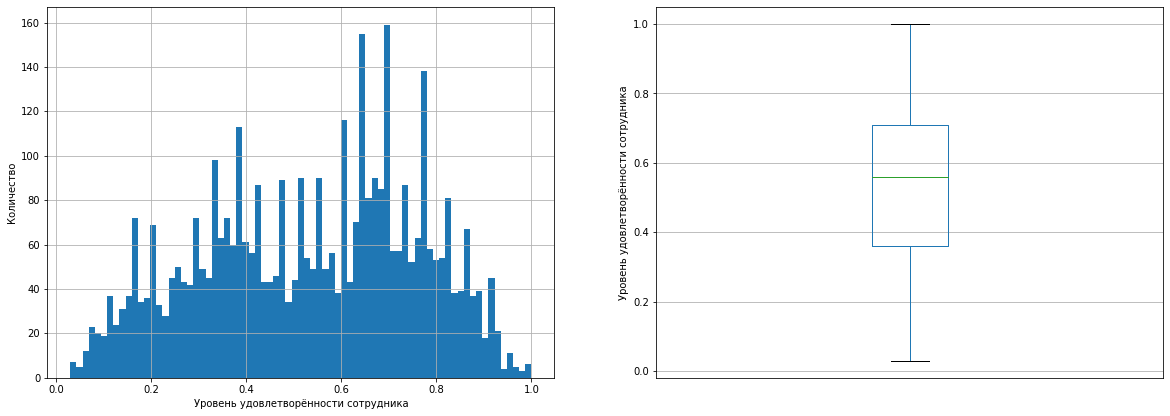

In [41]:
counting_param(train_select, ['salary', 'job_satisfaction_rate'], train_select_title_list,'Количество')

Из представленных гистограмм и диаграмм размахов видно следующее: выбросы в данных есть, но не везде; некоторые столбцы "чисты" - то есть там нет выбросов. 

Нужно рассмотреть выбросы в столбцах `'supervisor_evaluation'` и `'salary'` (`'Оценка качества работы сотрудника от руководителя'`, `'Зарплата(д.е.)'`), а после принимать решение об их удалении или нет. Выбросов в столбце `'salary'` много, это видно; однако удалять эти данные не стоит, так как из гистограммы видно, что данные распределены аномально; также можно предположить, что высокие зарплаты имеют критически важные сотрудники компании (к примеру, сеньоры, мидлы или сторудники, в таких должностях при высокой загруженноости). Выбросов в столбце `'supervisor_evaluation'` мало, и в удалении нет необходимости, так как их немного и искажение результатов исследования маловероятно.

Поэтому примем решение оставить все данные в том виде, в котором мы их и изучили, то есть не будет проводить **удаление выбросов**.

#### Рассмотрим категориальные переменные

Для того чтобы подсчитать количество значений в конкретном столбце категориальных переменных, воспользуемся методом `.value_counts()`; после для наглядности выведем круговую диаграмму этих значений.

Для оптимизации напишем функцию `dataframe_diagram()`, которая будет строить и выводить круговые диаграммы; в функцию будем передавать датафрейм, список необходимых столбцов и список заголовочных названий графиков: 

In [42]:
def dataframe_diagram(dataframe, data_list, title_list):
    for i,j in zip(data_list,title_list):
        plt.figure(figsize=(20, 15))
        plt.subplot(2, 2, 1)
        dataframe[i].value_counts().sort_values(ascending=True).plot(kind='barh')
        plt.ylabel(' ')
        plt.title(j)
        plt.legend()
        plt.subplot(2, 2, 2)
        dataframe[i].value_counts().plot(kind='pie', autopct='%.2f')
        plt.ylabel(' ')
        plt.title(j)
        plt.legend(bbox_to_anchor=(1, 0.6))
        plt.show()
        print(dataframe[i].value_counts())

In [43]:
# список заголовков для графиков
cat_list = ['Количество сторудников в отделах', 'Количество сотрудников по должностям', 
                        'Уровень загруженности сотрудника', 'Количество повышений за последний год', 
                         'Количество нарушений сотрудником трудового договора за последний год']

Воспользуемся ранее написанной функцией `dataframe_diagram()`:

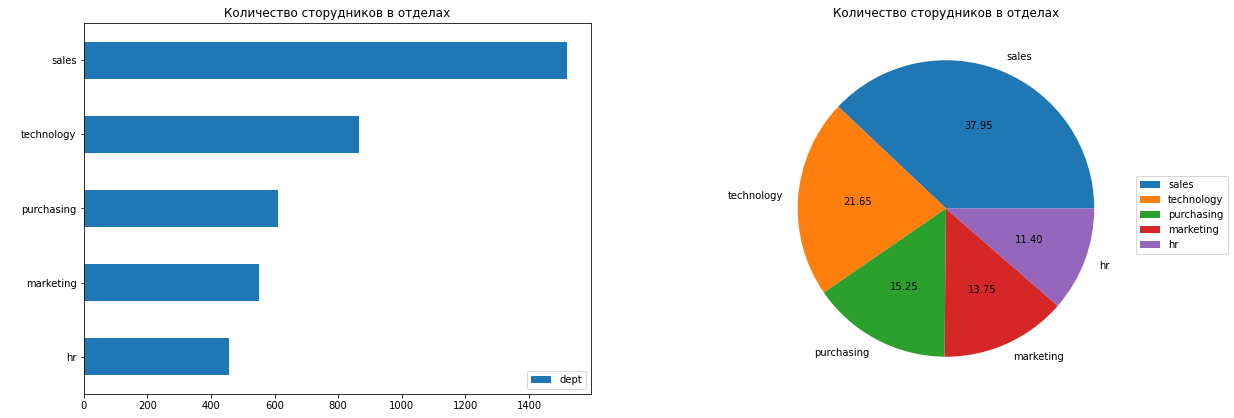

sales         1518
technology     866
purchasing     610
marketing      550
hr             456
Name: dept, dtype: int64


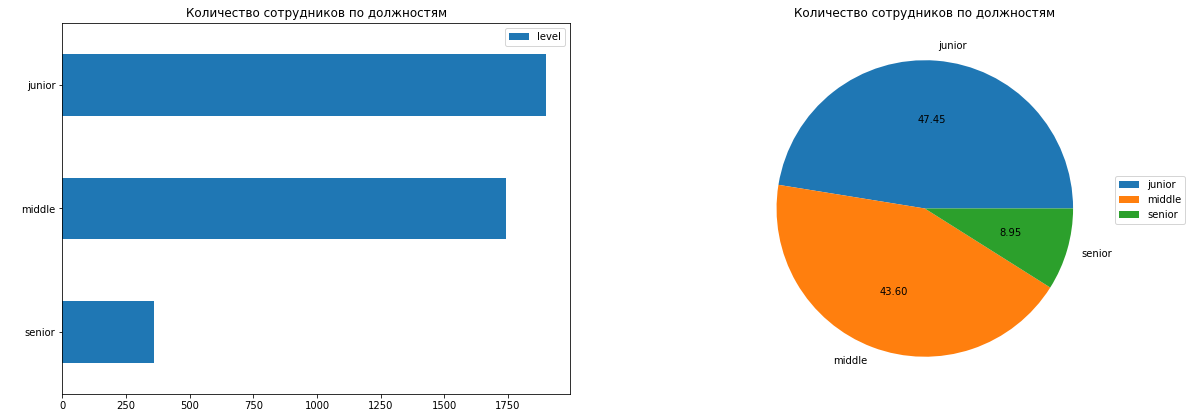

junior    1898
middle    1744
senior     358
Name: level, dtype: int64


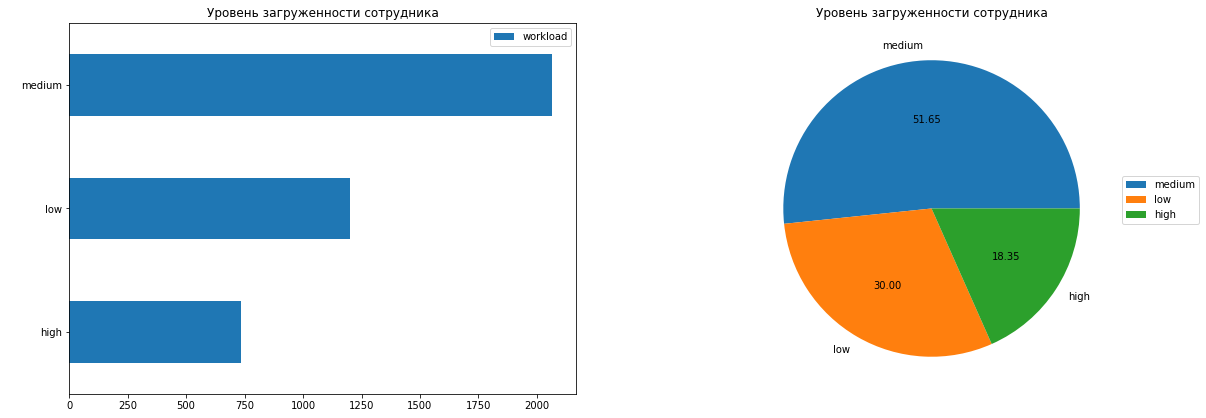

medium    2066
low       1200
high       734
Name: workload, dtype: int64


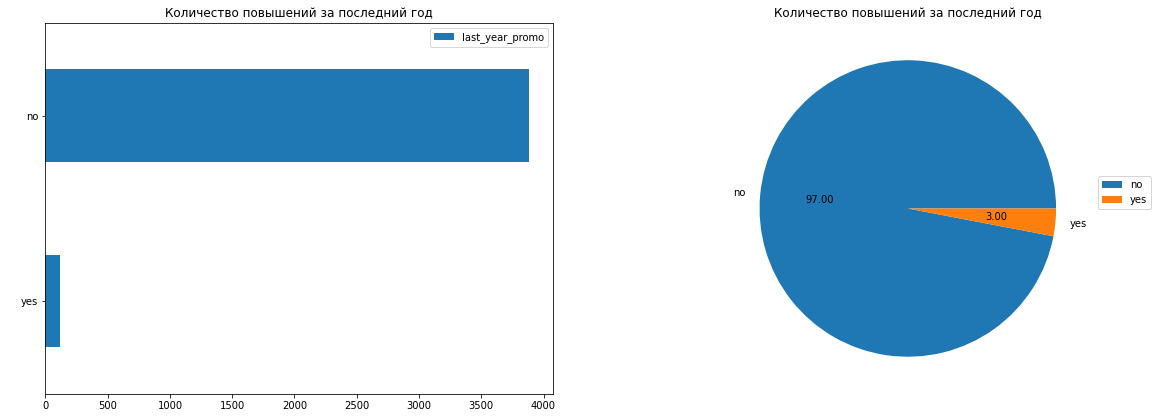

no     3880
yes     120
Name: last_year_promo, dtype: int64


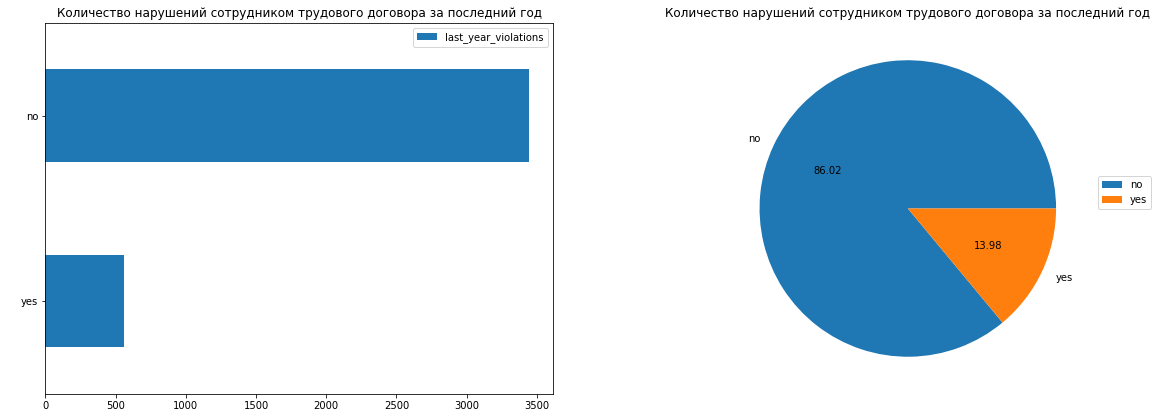

no     3441
yes     559
Name: last_year_violations, dtype: int64


In [44]:
dataframe_diagram(train_select, train_select.drop(columns = train_select.describe().columns).columns, cat_list)

Из полученных результатов можно говорить следующее:
- наиболее загружены отделы продаж (`sales`) и технологий (`technology`)
- сеньоры в компании составляют около 9%, мидлы - примерно 44%, джуны - около 47%
- чуть более 50% работников имеют средний уровень загруженности, 30% - низкий, 18% - высокий 
- только 3% сотрудников компании *повысили* за прошлый год, остальные 97% остались в той же должности
- 86% сотрудников *не нарушали* трудовой договор за последний год

#### Корреляционный анализ

**Проведём корреляционный анализ признаков в датасетах**

Изучим взаимосвязь между признаками в тренировочном датафрейме `train_select` - хорошим решением будет использовать коэффициент корреляции  𝜙𝐾, это передовой способ вычисления коэффициентов корреляции для любых типов признаков и не требует предварительного кодирования, этот коэффициент показывает не только линейные связи, но и нелинейные. Для этого воспользуемся методом `.phik_matrix()`, который возвращает коэффициенты корреляции 𝜙𝐾; перед этим удалим столбец `'id'`, так как он лишь показывает уникальный идентификатор покупателя, который никак не связан с остальными столбцами. 

In [45]:
phiK_mat = train_select.drop(columns=['id']).phik_matrix(interval_cols=['salary', 'job_satisfaction_rate'])

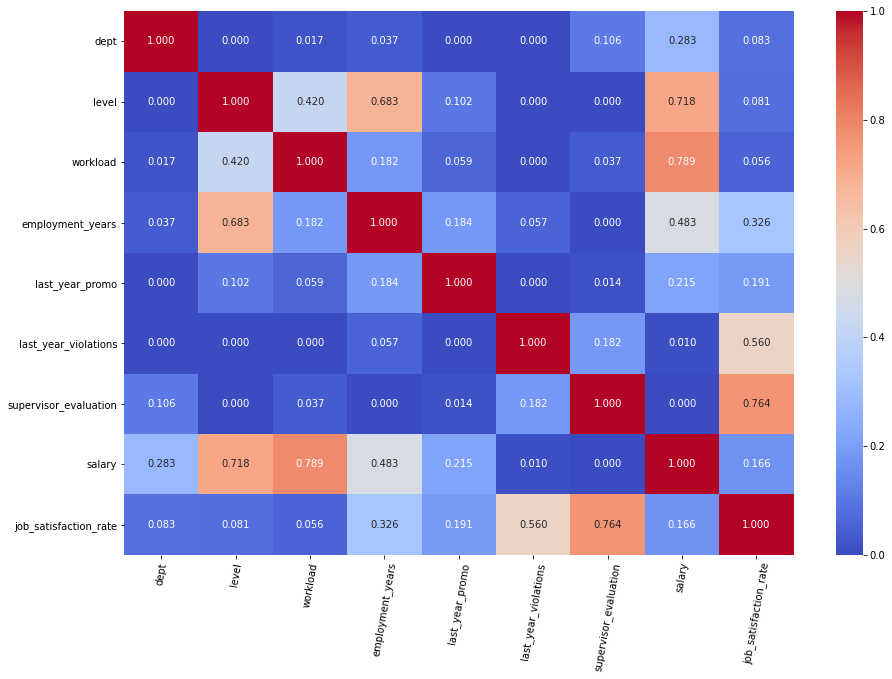

In [46]:
plt.figure(figsize=(15, 10))
sns.heatmap(phiK_mat, annot=True, fmt='.3f', cmap='coolwarm')
plt.xticks(rotation=80)
plt.show()

На тепловой карте удобно представлены результаты, по которым можно провести анализ. Согласно *шкале Чеддока* можно говорить о следующее: есть коррелирующие и некоррелирующие величины. Из тепловой карты наглядно видно: 
- **высокая** связь: '`level'`-`'salary'`, `'workload'`-`'salary'`, `'supervisor_evaluation'`-`'job_satisfaction_rate'`
- **заметная** связь: `'last_year_violations'`-`'job_satisfaction_rate'`, `'level'`-`'employment_years'`
- **умеренная** связь: `'employment_years'`-`'job_satisfaction_rate'`, `'employment_years'`-`'salary'`, `'workload'`-`'level'`
- остальные признаки имеют **слабую** связь или её вообще нет 

Из графика можно сказать, что говорить о **мультиколлениарности** тут нельзя.

В связи с этим никакие признаки из датафрейма удалять не нужно, так как они могут быть важны для дальнейшего исследования.

#### Сделаем выводы о данных

В результате исследования количественных признаков были получены следующие результаты:
- были проанализированы выбросы во всех датафреймах
- было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, а у некоторых крайне мало выбросов, что маловероятно повлияет на результаты исследования

В результате исследования категориальных признаков были получены следующие результаты:
- наиболее загружены отделы продаж (`sales`) и технологий (`technology`)
- сеньоры в компании составляют около 9%, мидлы - примерно 44%, джуны - около 47%
- чуть более 50% работников имеют средний уровень загруженности, 30% - низкий, 18% - высокий 
- только 3% сотрудников компании *повысили* за прошлый год, остальные 97% остались в той же должности
- 86% сотрудников *не нарушали* трудовой договор за последний год

В результате исследования корреляционного анализа были получены следующие результаты:
- построили тепловую карту матрицы корреляционных значений и проанализировали 
- сделали выводы о взаимосвязи признаков
- проанализировали и определили, что между признаками нет мультиколлениарности

###  Подготовка данных

Начнём подготовку признаков для дальнейшего обучения моделей.

Для начала посмотрим на размеры и убедимся в том, что тренировочные и тестовые данные имеют один и тот же размер:

In [47]:
train_select.shape

(4000, 10)

In [48]:
X_test.shape

(2000, 9)

In [49]:
y_test.shape

(2000, 2)

Тренировочные и тестовые данные имеют одно и тоже число строк соответственно. 

Выполним объединение тестовых данных по `id`, так как данные расположены не в том порядке, в котором нам необходимо для передачи в модели(если этот шаг не предпринять, то в дальнейшем результаты исследования сильно исказяться):

In [50]:
full_select = X_test.merge(y_test, on='id', how='inner')

Выведем для ознакомления первые строки получившегося датафрейма:

In [51]:
full_select.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79
1,686555,hr,junior,medium,1,no,no,4,30000,0.72
2,467458,sales,middle,low,5,no,no,4,19200,0.64
3,418655,sales,middle,low,6,no,no,4,19200,0.60
4,789145,hr,middle,medium,5,no,no,5,40800,0.75


Теперь столбец `'id'` в `train_select` преобразуем в индекс и снова проверим на наличие дубликатов данные переда разбитием их на входной и целевой признаки тренировочных данных:

In [52]:
train_select = train_select.set_index('id')

In [53]:
train_select.shape

(4000, 9)

In [54]:
train_select.duplicated().sum()

248

Как видно из повторной проверки есть дубликаты, в связи с этим удалим их: 

In [55]:
train_select = train_select.drop_duplicates(keep='first').reset_index(drop=False)

Проверим удаление:

In [56]:
train_select.shape

(3752, 10)

Удаление дубликатов прошло успешно.

Начнем деление на входные и целевые признаки тренировочных и тестовых данных соответственно:

In [57]:
X_train = train_select.drop(columns=['id', 'job_satisfaction_rate'], axis=1)
y_train = train_select['job_satisfaction_rate']
X_test_f = full_select.drop(columns=['id','job_satisfaction_rate'], axis=1)
y_test_f = full_select['job_satisfaction_rate']

Проверим размеры признаков:

In [58]:
display(X_train.shape)
display(y_train.shape)
display(X_test_f.shape)
display(y_test_f.shape)

(3752, 8)

(3752,)

(2000, 8)

(2000,)

Данные готовы для обучения моделей.

In [59]:
# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

Создадим пайплайны для подготовки признаков:

In [60]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
    )

In [61]:
# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'],
                    ['low', 'medium', 'high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [62]:
# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [63]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

**Промежуточный вывод:**

В результате подготовки данных были выполнены следующие шаги:
- проверили размеры данных(строки, столбцы)
- провели разделение на входные и целевые признаки для тренировочных и тестовых данных
- создали пайплайны для подготовки признаков

### Обучение моделей

Обучим как минимум две модели. Возьмём одну линейную модель, а в качестве второй — дерево решений. Подберем гиперпараметры как минимум для одной модели с помощью одного из известных инструментов.
Выберем лучшую модель и проверем её качество. Выбор сделаем на основе метрики — SMAPE (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»). 

Напишим функцию, которая принимает на вход массивы NumPy или объекты Series в pandas и возвращает значение метрики SMAPE. Будем использовать эту метрику при подборе гиперпараметров и оценке качества моделей. 

Метрика SMAPE вычисляется по следующей формуле:
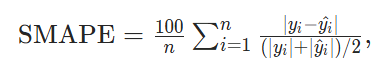



Критерий успеха: SMAPE ≤ 15 на тестовой выборке.

Сохраним решения со всеми моделями, которые пробовали, и сделаем выводы.

Напишем функцию `smape`, которая будет вычислять нашу метрику; в неё передаём два параметра: `y_true` и `y_pred` (истинные и предсказанные значения соответственно); после этого проводится проверка типа данных и преобразование в массив `NumPy`(то есть если передаваемые параметры объекты `pd.Series`, то они преобразуются в массивы NumPy); далее производится расчет числителя и знаменателя согласно представленной выше формуле метрики SMAPE; и в конце происходит осреднение и умножение на 100 и возвращение получившегося результата работы функции.

In [64]:
def smape(y_true, y_pred):
    if isinstance(y_true, pd.Series):
        y_true = y_true.values
    if isinstance(y_pred, pd.Series):
        y_pred = y_pred.values

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    numerator = np.abs(y_pred - y_true)
    denominator = ((np.abs(y_true) + np.abs(y_pred)) / 2)
    return np.mean(numerator/denominator) * 100

Создаём свою метрику с помощью `make_scorer()`:

In [65]:
# Создаём метрику
smape_score = make_scorer(smape, greater_is_better=False)

Для нахождения лучшей модели и гиперпараметров были выбраны следующие модели:
- `DecisionTreeRegressor()` с гипермараметрами:
    - `max_depth` - максимальная глубина дерева
    - `max_features` - максимальное количество признаков для поиска наилучшего разделения
- `KNeighborsRegressor()` с гипермараметрами:
    - `n_neighbors` - количество ближайших соседей, используемых для предсказания
- `SVR()` с гипермараметрами:
    - `kernel` - тип ядра
    - `C` - параметр регуляризации
    - `gamma` - параметр ядра
- `LinearRegression()`
- `RandomForestRegressor()` с гипермараметрами:
    - `n_estimators` - количество деревьев в лесу
    - `max_depth` - максимальная глубина дерева   
- `GradientBoostingRegressor()` с гипермараметрами:
    - `n_estimators` - количество деревьев
    - `learning_rate` - темп обучения
    - `max_depth` - максимальная глубина дерева
    
Для всех моделей `preprocessor__num` - это предобработка числовых признаков.

In [66]:
# Параметры для поиска
param_grid = [
    # словарь для модели DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 15),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },

    # словарь для модели KNeighborsRegressor() 
    {
        'models': [KNeighborsRegressor()],
        'models__n_neighbors': range(2,10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели SVC() 
    {
        'models': [SVR()],
        'models__kernel': ['rbf','sigmoid','poly'],
        'models__C': [0.1, 1, 10],
        'models__gamma': [0.1, 1, 10],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели LinearRegression()
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели RandomForestRegressor()
    {
        'models': [RandomForestRegressor(random_state=RANDOM_STATE)],
        'models__n_estimators': [10, 50, 100],
        'models__max_depth': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
      
    # словарь для модели GradientBoostingRegressor()
    {
        'models': [GradientBoostingRegressor(random_state=RANDOM_STATE)],
        'models__n_estimators': [10, 50, 100],
        'models__learning_rate': [0.01, 0.1, 1.0],
        'models__max_depth': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }

]

In [67]:
# Создаем пустые списки для таблицы результатов 
models = []
smape_train_result = []

С помощью цикла *for* будем перебирать каждую модель из `param_grid`, обучать на тренировочных данных, предсказывать результат на тестовыхх данных, находить метрику SMAPE, с помощью созданной ранее метрики `smape_score` и функции `smape`, выводить полученные результаты по рассмотренной модели и сохранять их для дальнейшего анализа. Также инициализируем класс `RandomizedSearchCV()` для для случайного поиска гиперпараметров с учётом ранее созданных параметров и пайплайнов и в качестве метрики, которой будем проводить оценку модели, будем использовать `SMAPE`:

In [68]:
for grid in param_grid:
    research = RandomizedSearchCV(
        pipe_final,
        grid,
        n_jobs=-1,
        cv=5,
        n_iter=5,
        scoring=smape_score,
        random_state=RANDOM_STATE
    )

    # обучение модели
    research.fit(X_train, y_train)
    research_best_model = research.best_estimator_['models']
    
    research_train_score = (-1) * research.best_score_

    print(research_best_model)
    print('SMAPE лучшей рассмотренной модели на кросс-валидации:', research_train_score, '\n\n')
    
    # сохранение результата рассмотренной модели
    models.append(research_best_model)
    smape_train_result.append(research_train_score)

DecisionTreeRegressor(max_depth=11, max_features=6, random_state=42)
SMAPE лучшей рассмотренной модели на кросс-валидации: 16.6744463283731 


KNeighborsRegressor(n_neighbors=2)
SMAPE лучшей рассмотренной модели на кросс-валидации: 17.444182153068645 


SVR(C=0.1, gamma=0.1)
SMAPE лучшей рассмотренной модели на кросс-валидации: 18.486017843971776 




/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LinearRegression()
SMAPE лучшей рассмотренной модели на кросс-валидации: 24.991163758388584 


RandomForestRegressor(max_depth=8, random_state=42)
SMAPE лучшей рассмотренной модели на кросс-валидации: 16.27810016087727 


GradientBoostingRegressor(max_depth=9, n_estimators=50, random_state=42)
SMAPE лучшей рассмотренной модели на кросс-валидации: 13.342819746935522 




In [69]:
# данные об исследованных моделей
datatable = {
    'model': models,
    'smape_train_result': smape_train_result,
}

In [70]:
result_table = pd.DataFrame(datatable)
result_table.sort_values(by='smape_train_result')

,model,smape_train_result
5,([DecisionTreeRegressor(criterion='friedman_ms...,13.342820
4,"(DecisionTreeRegressor(max_depth=8, max_featur...",16.278100
0,"DecisionTreeRegressor(max_depth=11, max_featur...",16.674446
1,KNeighborsRegressor(n_neighbors=2),17.444182
2,"SVR(C=0.1, gamma=0.1)",18.486018
3,LinearRegression(),24.991164


Из проведенного исследования на качество метрики SMAPE у выбранных моделей, условию - тестовая метрика должна быть меньше или равна 15 - удовлетворяют следующие модели с гиперпараметрами:
- GradientBoostingRegressor(max_depth=9, n_estimators=50, random_state=42): smape_test_result = 11.989596
- DecisionTreeRegressor(max_depth=11, max_features=6, random_state=42): smape_test_result = 14.255920
- RandomForestRegressor(max_depth=8, random_state=42): smape_test_result = 14.879761

Из представленных результатов можно говорить, что модель `GradientBoostingRegressor()` показала себя лучше всего с результатом SMAPE 13.342820.

Повторно проведем исследование моделей, но уже не всех:

In [71]:
# Параметры для поиска
param_grid_2 = [
    
    # словарь для модели RandomForestRegressor()
    {
        'models': [RandomForestRegressor(random_state=42)],
        'models__n_estimators': [10, 50, 100],
        'models__max_depth': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
      
    # словарь для модели GradientBoostingRegressor()
    {
        'models': [GradientBoostingRegressor(random_state=42)],
        'models__n_estimators': [10, 50, 100],
        'models__learning_rate': [0.01, 0.1, 1.0],
        'models__max_depth': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }

]

In [72]:
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid_2,
    n_jobs=-1,
    n_iter=75,
    cv=5,
    scoring=smape_score,
    random_state=RANDOM_STATE
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)

print('SMAPE лучшей модели на кросс-валидации:', ((-1) * randomized_search.best_score_), '\n')

# Проверяем модель на тестовой выборке
y_test_pred = randomized_search.best_estimator_.predict(X_test_f)
print(f'SMAPE на тестовой выборке: {smape(y_test_f, y_test_pred)} \n\n')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                            

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


При повторном изучении можно наблюдать, что результат метрики SMAPE улучшился, так как стал немного ниже предыдущего. В связи с этим будем использовать модель `GradientBoostingRegressor(max_depth=7, random_state=42)` для дальнейшего исследования.

**Оценим важность признаков для лучшей модели**

Сохраним в `random_best_model` лучшую модель, которая была найдена: 

In [73]:
# лучшая модель 
random_best_model = randomized_search.best_estimator_.named_steps['models']

# preprocessor лучшей модели
preprocessor_best_model = randomized_search.best_estimator_['preprocessor']

In [74]:
# подготовка данных с помощью preprocessor_best_model
X_train_preproc = preprocessor_best_model.transform(X_train)
X_test_preproc = preprocessor_best_model.transform(X_test)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [75]:
# получение имен признаков после препроцессинга
ohe_columns_bm = preprocessor_best_model.named_transformers_['ohe'].get_feature_names_out(input_features=ohe_columns)
ord_columns_bm = preprocessor_best_model.named_transformers_['ord'].get_feature_names_out(input_features=ord_columns)
num_columns_bm = preprocessor_best_model['num'].get_feature_names_out(num_columns)
columns_name_list = preprocessor_best_model.get_feature_names_out()

In [76]:
# создание DataFrame с трансформированными данными
X_train_preproc = pd.DataFrame(X_train_preproc, columns=columns_name_list)
X_test_preproc = pd.DataFrame(X_test_preproc, columns=columns_name_list)

In [77]:
# обучение лучшей модели
random_best_model.fit(X_train_preproc, y_train)

GradientBoostingRegressor(max_depth=7, random_state=42)

In [78]:
explainer_1 = shap.Explainer(random_best_model.predict, X_train_preproc)
shap_values_1 = explainer_1(X_test_preproc)

PermutationExplainer explainer: 2001it [04:27,  7.30it/s]                          


Построим график важности с помощью метода SHAP:

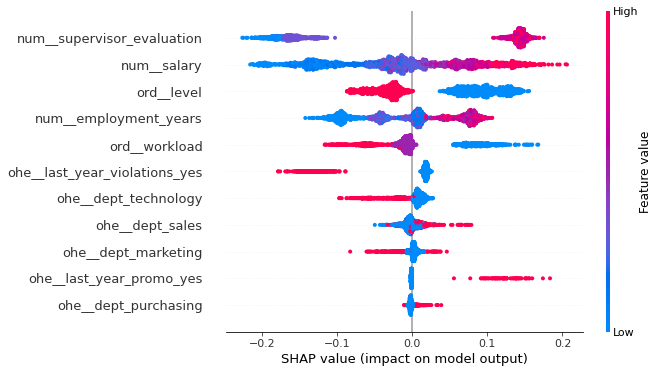

In [79]:
# Построение графика с именами признаков
shap.plots.beeswarm(shap_values_1, max_display=21)

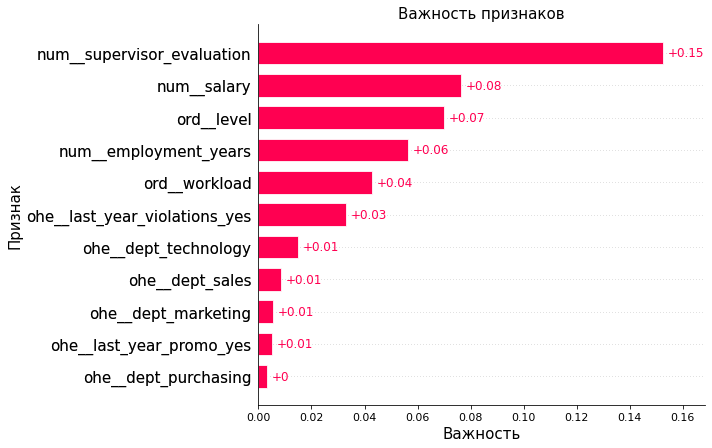

In [80]:
shap.plots.bar(shap_values_1, max_display=21, show=False)
plt.yticks(fontsize=15)
plt.xlabel('Важность', fontsize=15)
plt.ylabel('Признак', fontsize=15)
plt.title('Важность признаков', fontsize=15);

Из результатов графика можно сказать следующее:
- признаки, расположенные в верхней части графика, имеют наибольшее влияние на предсказания модели, а в нижней части - меньшее влияние
- положительные значения указывают на то, что признак увеличивает предсказание модели, а отрицательные значения - признак уменьшает предсказание модели
- красные точки (высокие значения признаков) и синие точки (низкие значения признаков) показывают, как различные значения признаков влияют на предсказания

Из представленных графиков следует, что *наибольшее* влияние имеют признаки: `supervisor_evaluation`, `level`, `salary`, `employment_years` и `workload`; а *наименьшее* - `dept` - отдел `purchasing`, `dept` - отдел `marketing`, `last_year_promo` - сотрудники у которых было повышение.

**Сделаем выводы о значимости признаков**

В результате оценки важности признаков были получены следующие результаты:
- наименее значимые признаки для модели были определены:
    - `dept`
    - `last_year_promo`
- наиболее значимые признаки для модели были определены:
    - `supervisor_evaluation`
    - `level`
    - `salary`
    - `employment_years`
    - `workload`
    
Признак `supervisor_evaluation` говорит о том, что чем выше оценки руководителя, тем выше увеличивают предсказанный уровень удовлетворенности. Признак `level` показывает, что низкий уровень должности может снижать уровень удовлетворенности. Признак `salary` показывает, что чем выше зарплата, тем удовлетворенее сотрудник (с этим нельзя не согласиться). Признак `employment_years` указывает, что чем дольше сотрудник работает в компании, тем более он удовлетворен, так как скорее он уже привык к сложившейся в ней атмосфере. Признак `workload` говорит о том, что чем выше нагрузка на сотрудника, тем он менее он удовлетворен, так как пытается решить все задачи, которые ему дали и находится в стрессовых условиях. 

Отдел, в котором работает сотрудник - `dept` - и повышение за последний год - `last_year_promo` - наименьше всего влияют, так как в каждом отделе свой устрой и повышений очень-очень мало, поэтому по этим показателям трудно говорить об удовлетворенности сотрудников.

### Оформление выводов

Из проведенных исследований можно говорить о следующем:
- данные были разделены на одни и те же размеры
- была создана собственная метрика SMAPE и функция для её вычисления smape(), согласно формуле
- для нахождения лучшей модели были выбраны следующие: 
    - `DecisionTreeRegressor()`
    - `KNeighborsRegressor()`
    - `SVR()`
    - `LinearRegression()`
    - `RandomForestRegressor()`   
    - `GradientBoostingRegressor()`
    
Из проведенных вычислений метрики SMAPE и переборе разных гипермараметров в моделях лучше всего справилась модель `GradientBoostingRegressor()` с гиперпараметрами `max_depth=9`, `n_estimators=50`, `random_state=42` и результатом метрики SMAPE на кросс-валидации `13.342820`, что удовлетворяет требованию и является минимальным из всех рассмотренных моделей. После повторного изучения уже данного метода в отдельности результат метрики SMAPE на тестовой выборке удалось получить `11.138166` и моделью `GradientBoostingRegressor()` с гиперпараметрами `max_depth=7`, `random_state=42`.

Согласно изученной информации из открытых источников, была выбрана модель `GradientBoostingRegressor()` - модель градиентного бустинга - засчёт последовательного построения деревьев решений, каждое из которых пытается исправить ошибки предыдущих, и постепенно улучшать свои прогнозы.Также этот метод часто дает высокую точность на задачах регрессии, которую в данном случае мы и изучаем.

## Задача 2: Предсказание увольнения сотрудника из компании

### Загрузка данных

**Загрузим данные**

Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы.

In [81]:
train_select_2 = pd.read_csv('/datasets/train_quit.csv')
X_test_2 = X_test
y_test_2 = pd.read_csv('/datasets/test_target_quit.csv')

Выведем первые строки датафреймов, чтобы проверить, правильно ли считались данные:

In [82]:
train_select_2.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [83]:
X_test_2.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [84]:
y_test_2.head()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


Можно говорить о том, что CSV-файлы считались правильно, и с такими датафреймами уже можно работать.

### Предобработка данных

Изучим данные и при необходимости выполним предобработку.

#### Изучим общую информацию о датафреймах

Теперь для лучшего понимания данных, хранящихся в датафреймах, выведем информацию о них методом `.info()`:

In [85]:
train_select_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


In [86]:
X_test_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   2000 non-null   object
 2   level                  2000 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [87]:
y_test_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


Проанализировав информацию о датафреймах, можно говорить, что все типы данных **соответствуют** в действительности самим данным - то есть необходимости изменять их тип - **нет**. Однако было замечено, что некоторые строки в датафреймах нулевые. Также стоит отметить, что все столбцы имеют "*стандартизированный вид*", то есть: латинский алфавит, прописные буквы, "змеевидная запись"(через нижнее подчеркивание).

#### Проверим наличие пропусков в данных

Воспользуемся методом `.isna()` для поиска пропусков во всех датафреймах и просуммируем их методом `.sum()`:

In [88]:
train_select_2.isna().sum()

id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
dtype: int64

In [89]:
X_test_2.isna().sum()

id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

In [90]:
y_test_2.isna().sum()

id      0
quit    0
dtype: int64

Из результатов вывода видно, что пропусков в данных нет.

#### Проверим данные на наличие дубликатов

После проверки датафреймов на наличие пропусков, проверим их на наличие дубликатов:

Воспользуемся методом `.duplicated()`, чтобы найти *явные* дубликаты в датафрейме и после методом `.sum()` выведем их количество:

In [91]:
train_select_2.duplicated().sum()

0

In [92]:
X_test_2.duplicated().sum()

0

In [93]:
y_test_2.duplicated().sum()

0

В результате наблюдаем, что *явных* дубликатов нет.

Теперь проверим данные на наличие *неявных* дубликатов, которые также могут встретиться. Для этого необходимо будет проверить все категориальные столбцы с данными на уникальность методом `.unique()`. Так как столбцов с данными много, то воспользуемся ранее написанной функцией `unique_search()`:

In [94]:
unique_search(train_select_2, 'train_select_2', train_select_2.drop(columns = train_select_2.describe().columns).columns)


Датафрейм train_select_2, столбец <dept>:

['sales' 'purchasing' 'marketing' 'technology' 'hr']

Датафрейм train_select_2, столбец <level>:

['middle' 'junior' 'sinior']

Датафрейм train_select_2, столбец <workload>:

['high' 'medium' 'low']

Датафрейм train_select_2, столбец <last_year_promo>:

['no' 'yes']

Датафрейм train_select_2, столбец <last_year_violations>:

['no' 'yes']

Датафрейм train_select_2, столбец <quit>:

['no' 'yes']


In [95]:
unique_search(X_test_2, 'X_test_2', X_test_2.drop(columns = X_test_2.describe().columns).columns)


Датафрейм X_test_2, столбец <dept>:

['marketing' 'hr' 'sales' 'purchasing' 'technology' ' ']

Датафрейм X_test_2, столбец <level>:

['junior' 'middle' 'sinior']

Датафрейм X_test_2, столбец <workload>:

['medium' 'low' 'high' ' ']

Датафрейм X_test_2, столбец <last_year_promo>:

['no' 'yes']

Датафрейм X_test_2, столбец <last_year_violations>:

['no' 'yes']


In [96]:
unique_search(y_test_2, 'train_select', y_test_2.drop(columns = y_test_2.describe().columns).columns)


Датафрейм train_select, столбец <quit>:

['yes' 'no']


Из результатов проверки на уникальность видно, что есть данные в столбцах, которые написаны либо неправильно, либо обозначают одно и тоже. 


Заменим методом `.replace()` неправильные названия в ячейках столбцов датафрейма:

In [97]:
train_select_2['level'] = train_select_2['level'].replace('sinior','senior')

In [98]:
unique_search(train_select_2, 'train_select_2', train_select_2.drop(columns = train_select_2.describe().columns).columns)


Датафрейм train_select_2, столбец <dept>:

['sales' 'purchasing' 'marketing' 'technology' 'hr']

Датафрейм train_select_2, столбец <level>:

['middle' 'junior' 'senior']

Датафрейм train_select_2, столбец <workload>:

['high' 'medium' 'low']

Датафрейм train_select_2, столбец <last_year_promo>:

['no' 'yes']

Датафрейм train_select_2, столбец <last_year_violations>:

['no' 'yes']

Датафрейм train_select_2, столбец <quit>:

['no' 'yes']


Видно, что изменения были успешно выполнены.

**Промежуточный вывод:**

В результате предобработки данных были выполнены следующие шаги:
- изучили основную информацию о датафреймах
- определили, что типы данных соответствуют действительности
- определили, что названия столбцов имеют правильную запись
- проверили данные на наличие пропусков
- проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
- преобразовали неявные дубликаты там, где это было возможно

### Исследовательский анализ данных

**Проведём статистический анализ всех признаков**

Как ранее можно было заметить в датафреймах присутствуют как категориальные, так и количественные переменные. В связи с эти требуется отдельная обработка для данных каждого типа.

#### Рассмотрим количественные переменные

Воспользуемся методом `.describe()` для того, что вывести все признаки количественных переменных в датафреймах.

In [99]:
train_select_2.drop(columns='id').describe()

,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000
mean,3.701500,3.474750,33805.800000
std,2.541852,1.004049,15152.415163
min,1.000000,1.000000,12000.000000
25%,2.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,96000.000000


In [100]:
X_test_2.drop(columns='id').describe()

,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000
mean,3.666500,3.526500,34066.800000
std,2.537222,0.996892,15398.436729
min,1.000000,1.000000,12000.000000
25%,1.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,96000.000000


Из представленных описательных характеристик можно говорить о том, что данные, в принципе, довольно хорошо представлены. Проверим данные на наличие выбросов построением диаграммы размаха("ящика с усами") и сделаем выводы о данных.

Для упрощения работы вызовем ранее созданную функцию `counting_param()`, которая будет визуализировать гистограмму и "ящик с усами" в зависимости от передаваемых параметров:

In [101]:
bar_2_title_list = (['Длительность работы(в годах)','Оценка качества работы сотрудника от руководителя'])
count_par_2_title_list = (['Зарплата(д.е.)'])

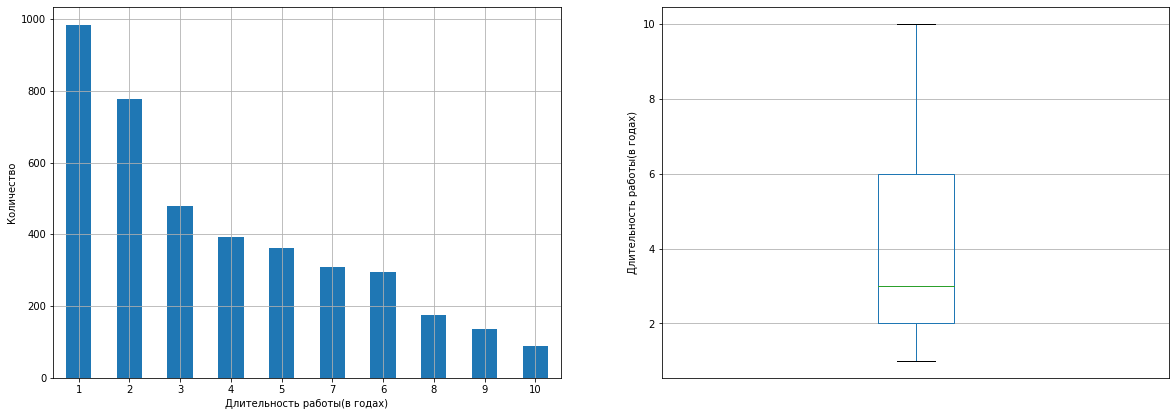

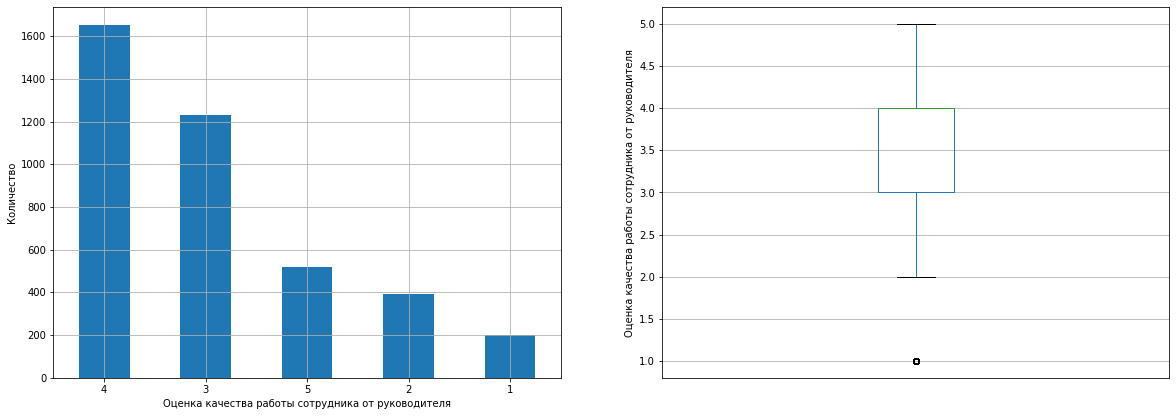

In [102]:
bar_diagram(train_select_2, ['employment_years', 'supervisor_evaluation'], bar_2_title_list,'Количество')

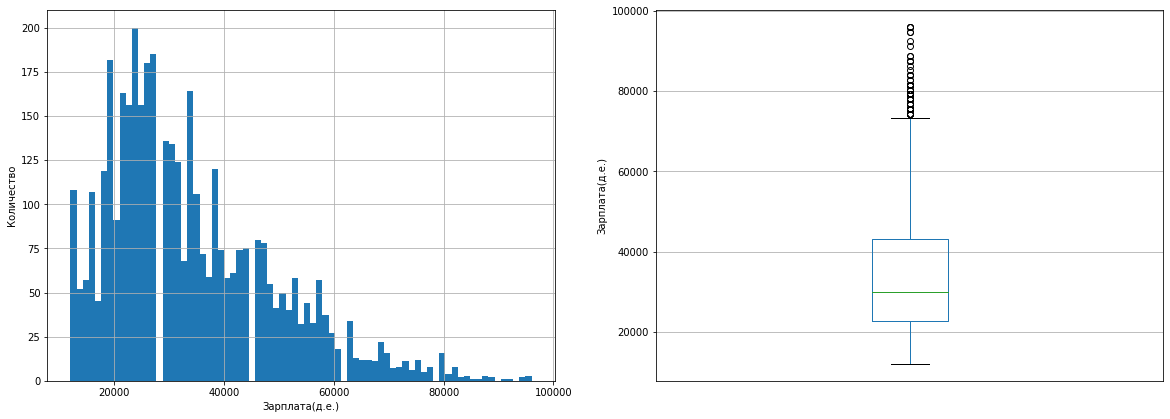

In [103]:
counting_param(train_select_2, ['salary'], count_par_2_title_list,'Количество')

Из представленных гистограмм и диаграмм размахов видно следующее: выбросы в данных есть, но не везде; некоторые столбцы "чисты" - то есть там нет выбросов. 

Нужно рассмотреть выбросы в столбцах `'supervisor_evaluation'` и `'salary'` (`'Оценка качества работы сотрудника от руководителя'`, `'Зарплата(д.е.)'`), а после принимать решение об их удалении или нет. Выбросов в столбце `'salary'` много, это видно; однако удалять эти данные не стоит, так как из гистограммы видно, что данные распределены аномально; также можно предположить, что высокие зарплаты имеют критически важные сотрудники компании (к примеру, сеньоры, мидлы или сторудники, в таких должностях при высокой загруженноости). Выбросов в столбце `'supervisor_evaluation'` мало, и в удалении нет необходимости, так как их немного и искажение результатов исследования маловероятно.

Поэтому примем решение оставить все данные в том виде, в котором мы их и изучили, то есть не будет проводить **удаление выбросов**.

#### Рассмотрим категориальные переменные

Для того чтобы подсчитать количество значений в конкретном столбце категориальных переменных, воспользуемся методом `.value_counts()`; после для наглядности выведем круговую диаграмму этих значений.

Воспользуемся ранее написанной функцией `dataframe_diagram()`, которая будет строить и выводить круговые диаграммы; в функцию будем передавать датафрейм, список необходимых столбцов и список заголовочных названий графиков: 

In [104]:
cat_list_2 = ['Количество сторудников в отделах', 'Количество сотрудников по должностям', 
              'Уровень загруженности сотрудника', 'Количество повышений за последний год', 
              'Количество нарушений сотрудником трудового договора за последний год', 'Количество сотрудников уволившихся из компании']

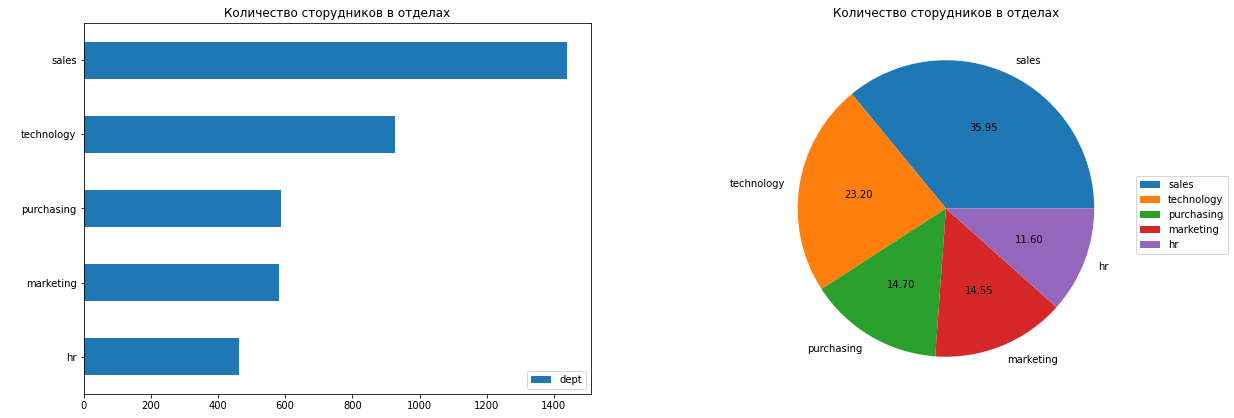

sales         1438
technology     928
purchasing     588
marketing      582
hr             464
Name: dept, dtype: int64


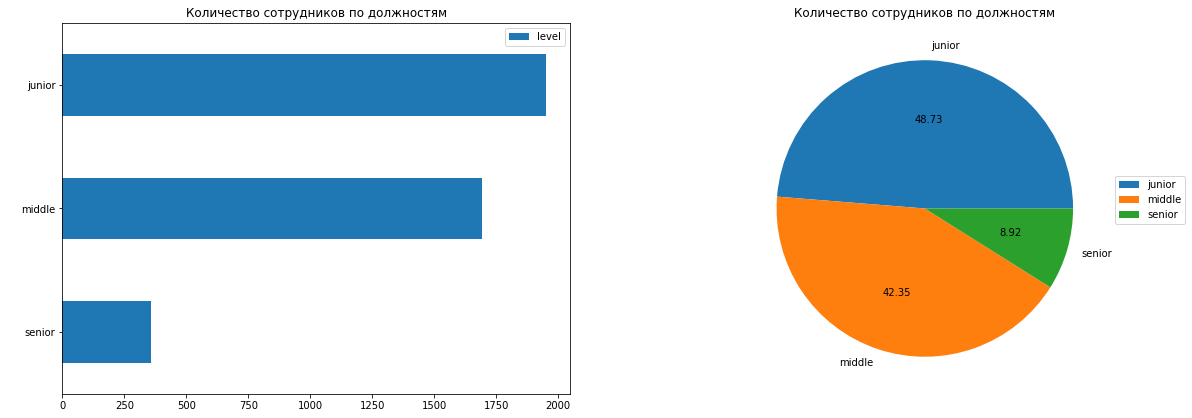

junior    1949
middle    1694
senior     357
Name: level, dtype: int64


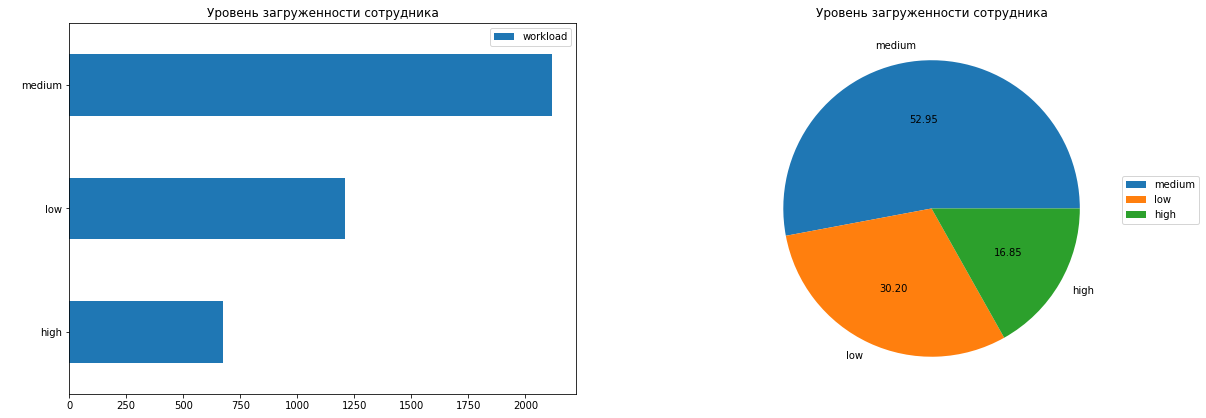

medium    2118
low       1208
high       674
Name: workload, dtype: int64


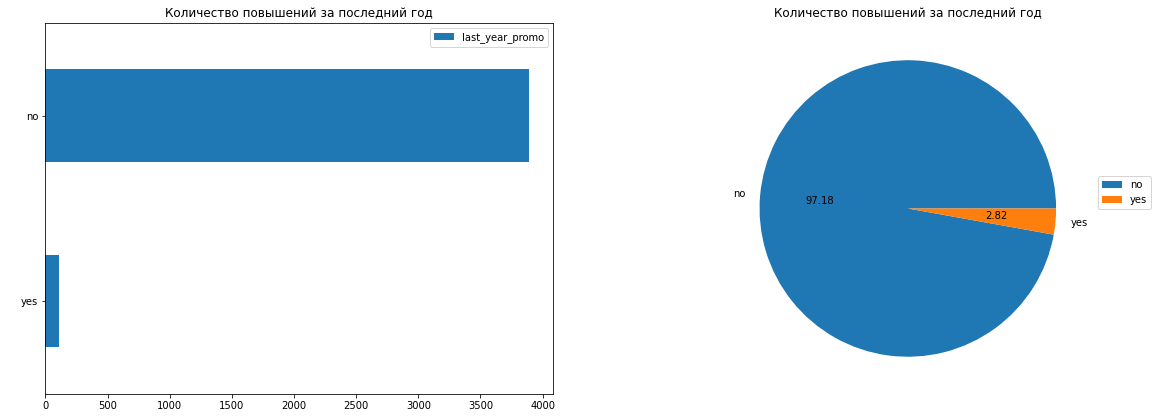

no     3887
yes     113
Name: last_year_promo, dtype: int64


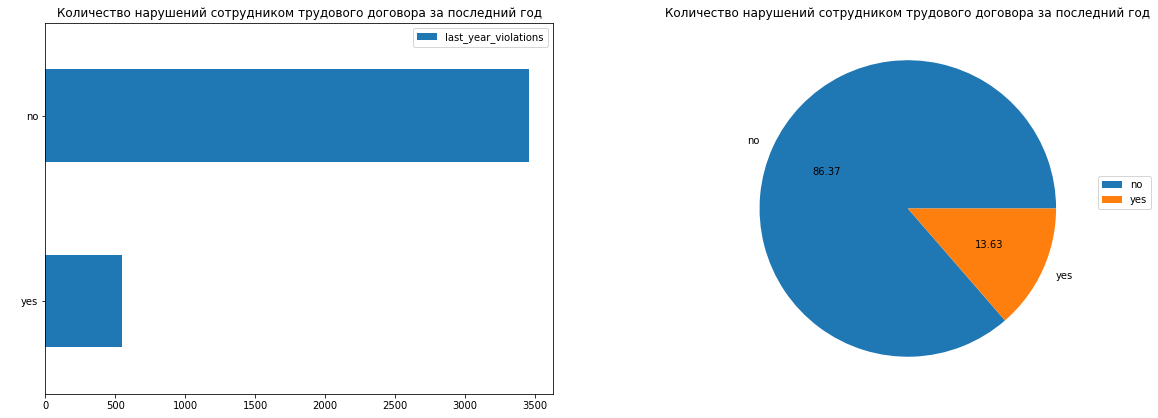

no     3455
yes     545
Name: last_year_violations, dtype: int64


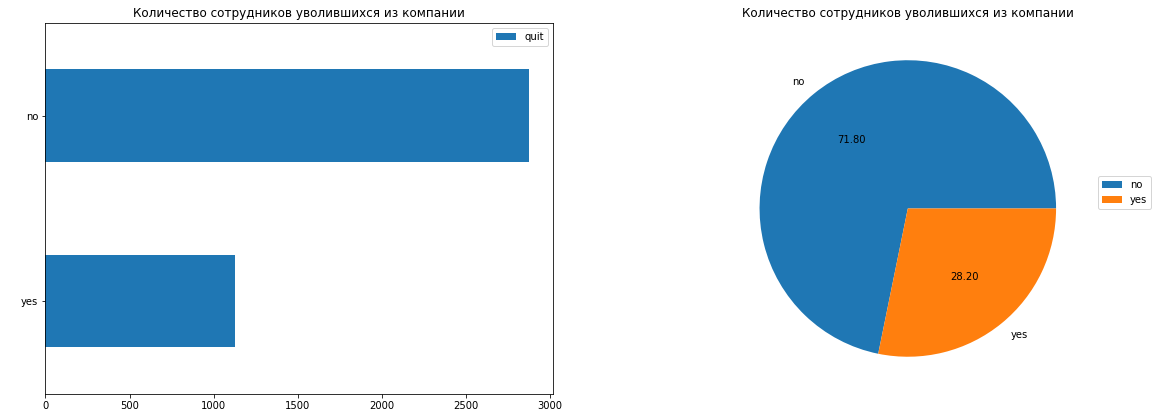

no     2872
yes    1128
Name: quit, dtype: int64


In [105]:
dataframe_diagram(train_select_2, train_select_2.drop(columns = train_select_2.describe().columns).columns, cat_list_2)

Из полученных результатов можно говорить следующее:
- наиболее загружены отделы продаж (`sales`) и технологий (`technology`)
- сеньоры в компании составляют около 9%, мидлы - примерно 42%, джуны - около 49%
- чуть более 50% работников имеют средний уровень загруженности, 30% - низкий, около 17% - высокий 
- менее 3% сотрудников компании *повысили* за прошлый год, остальные же остались в той же должности
- 86% сотрудников *не нарушали* трудовой договор за последний год
- около 28% сотрудников уволились из комппании

#### Корреляционный анализ

**Проведём корреляционный анализ признаков в датасетах**

Изучим взаимосвязь между признаками в тренировочном датафрейме `train_select_2` - хорошим решением будет использовать коэффициент корреляции  𝜙𝐾, это передовой способ вычисления коэффициентов корреляции для любых типов признаков и не требует предварительного кодирования, этот коэффициент показывает не только линейные связи, но и нелинейные. Для этого воспользуемся методом `.phik_matrix()`, который возвращает коэффициенты корреляции 𝜙𝐾; перед этим удалим столбец `'id'`, так как он лишь показывает уникальный идентификатор покупателя, который никак не связан с остальными столбцами. 

In [106]:
phiK_mat_2 = train_select_2.drop(columns=['id']).phik_matrix(interval_cols=['salary'])

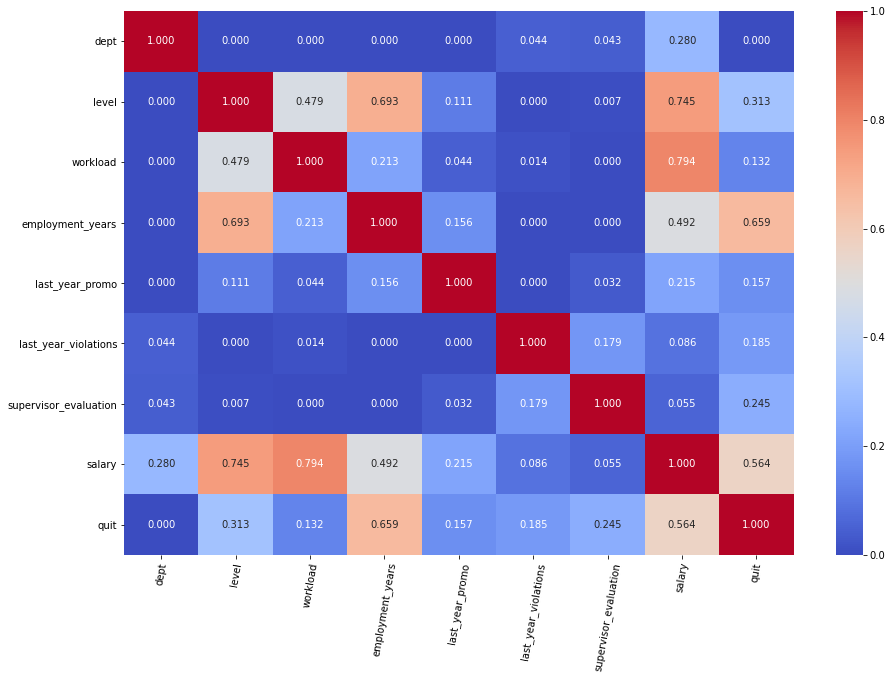

In [107]:
plt.figure(figsize=(15, 10))
sns.heatmap(phiK_mat_2, annot=True, fmt='.3f', cmap='coolwarm')
plt.xticks(rotation=80)
plt.show()

На тепловой карте удобно представлены результаты, по которым можно провести анализ. Согласно *шкале Чеддока* можно говорить о следующее: есть коррелирующие и некоррелирующие величины. Из тепловой карты наглядно видно: 
- **высокая** связь: '`level'`-`'salary'`, `'workload'`-`'salary'`
- **заметная** связь: `'salary'`-`'quit'`, `'employment_years'`-`'quit'`, `'employment_years'`-`'level'`
- **умеренная** связь: `'salary'`-`'quit'`, `'employment_years'`-`'salary'`, `'workload'`-`'level'`
- остальные признаки имеют **слабую** связь или её вообще нет 

Из графика можно сказать, что говорить о **мультиколлениарности** тут нельзя.

В связи с этим никакие признаки из датафрейма удалять не нужно, так как они могут быть важны для дальнейшего исследования.

#### Составим портрет «уволившегося сотрудника»

Составим портрет «уволившегося сотрудника». Например, можно узнать, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Также можно сравнить среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.

Разобьем датафрейм `train_select_2` на уволившихся и оставшихся сотрудников:

In [108]:
# данные об уволившихся сотрудниках 
fired_workers = train_select_2.query('quit == "yes"')

# данные об оставшихся сотрудниках
contin_workers = train_select_2.query('quit == "no"')

Создадим функцию `dataframe_bar_diagram`, которая будет строить столбцатые диаграммы(в нашем случае для уволенных и оставшихся), в которую будем передавать два датафрейма, список столбцов и список с подписями для графиков:

In [109]:
def dataframe_bar_diagram(dataframe, dataframe_2, data_list, title_list):
    for i,j in zip(data_list,title_list):
        plt.figure(figsize=(20, 15))
        plt.subplot(2, 2, 1)
        dataframe[i].value_counts().plot(kind='bar',  grid=True, color='red')
        plt.xticks(rotation=0)
        plt.ylabel(' ')
        plt.title(j)
        plt.legend(['уволились'])
        plt.subplot(2, 2, 2)
        dataframe_2[i].value_counts().plot(kind='bar',  grid=True, color='blue')
        plt.xticks(rotation=0)
        plt.ylabel(' ')
        plt.title(j)
        plt.legend(['остались'])
        plt.show()
        print(dataframe[i].value_counts())
        print(dataframe_2[i].value_counts())

In [110]:
# создаем список с заголовками графиков
cat_list = (['Отдел работы сотрудника', 'Должность сотрудника', 'Загруженность сотрудника', 
            'Длительность работы в компании (в годах)', 'Повышение сотрудника за последний год', 
             'Нарушение сотрудником трудового договора за последний год', 'Оценка качества работы сотрудника от руководителя'])

Вызовем ранее созданную функцию `dataframe_bar_diagram`:

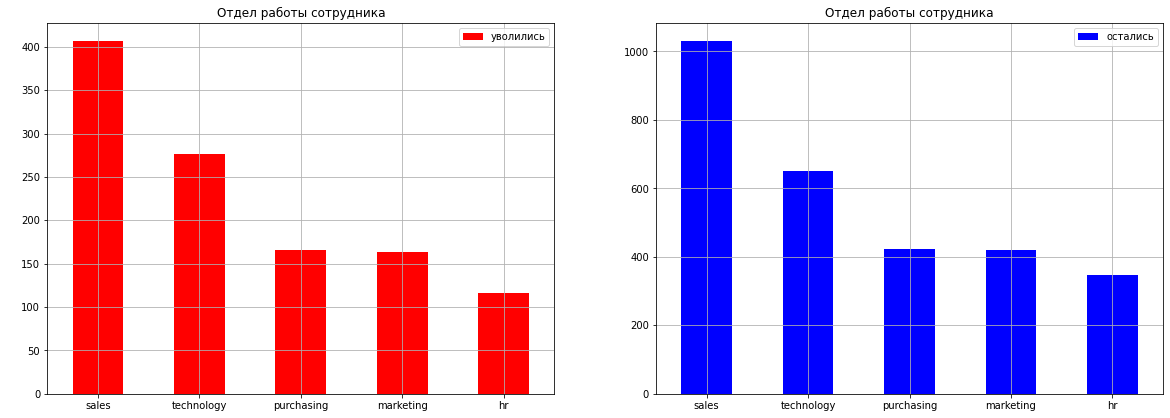

sales         407
technology    276
purchasing    166
marketing     163
hr            116
Name: dept, dtype: int64
sales         1031
technology     652
purchasing     422
marketing      419
hr             348
Name: dept, dtype: int64


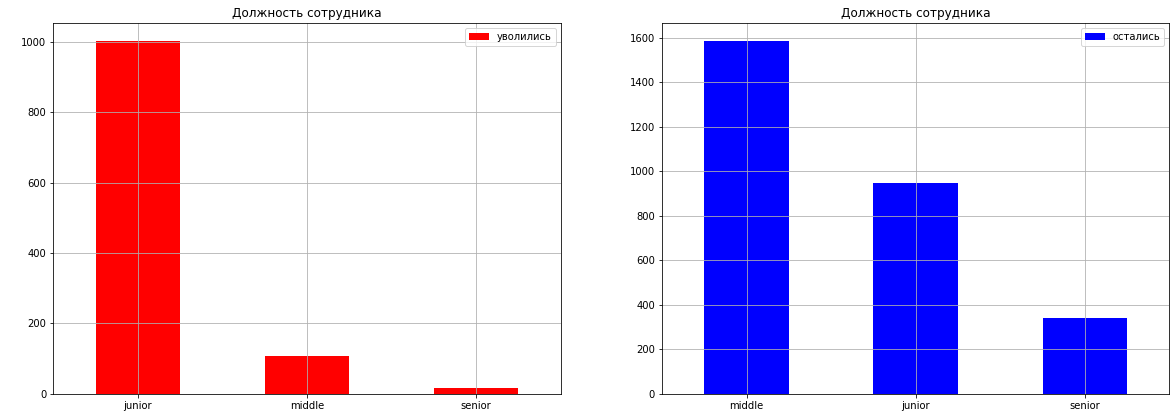

junior    1003
middle     108
senior      17
Name: level, dtype: int64
middle    1586
junior     946
senior     340
Name: level, dtype: int64


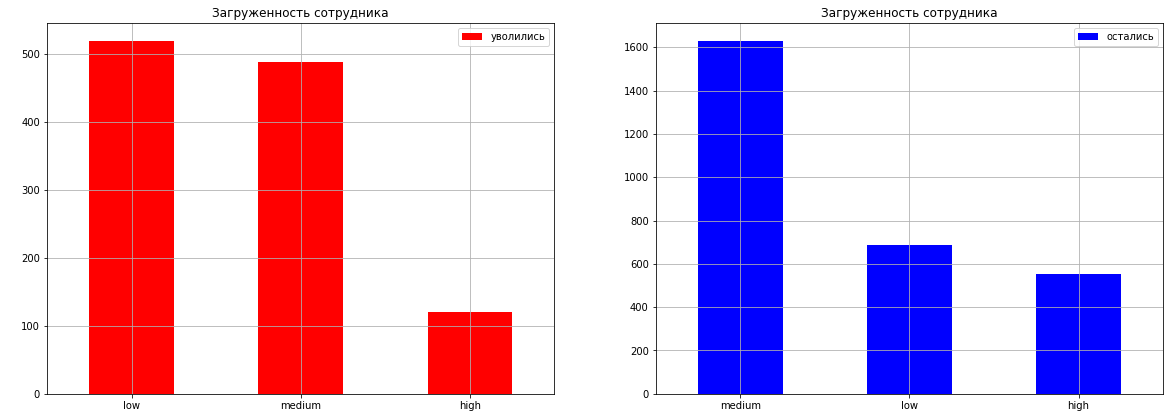

low       519
medium    488
high      121
Name: workload, dtype: int64
medium    1630
low        689
high       553
Name: workload, dtype: int64


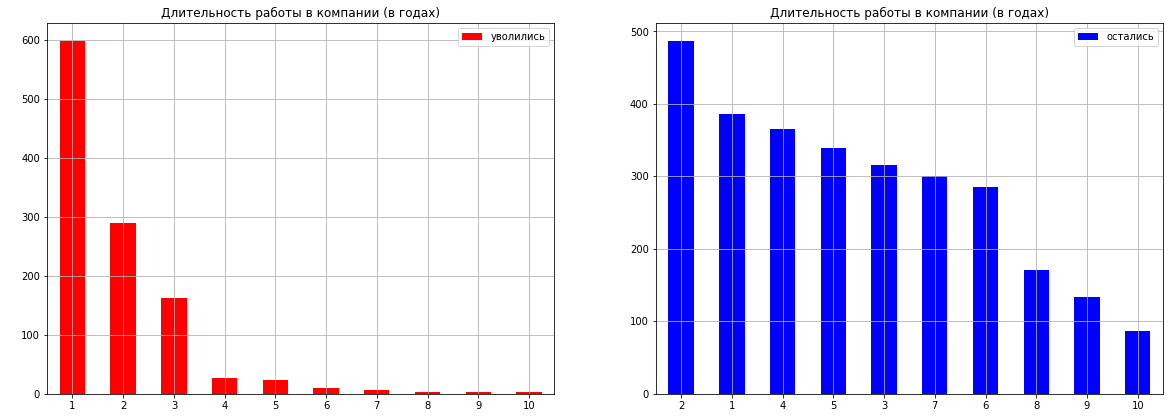

1     599
2     290
3     163
4      27
5      23
6      10
7       7
8       3
9       3
10      3
Name: employment_years, dtype: int64
2     487
1     386
4     366
5     339
3     316
7     301
6     286
8     171
9     133
10     87
Name: employment_years, dtype: int64


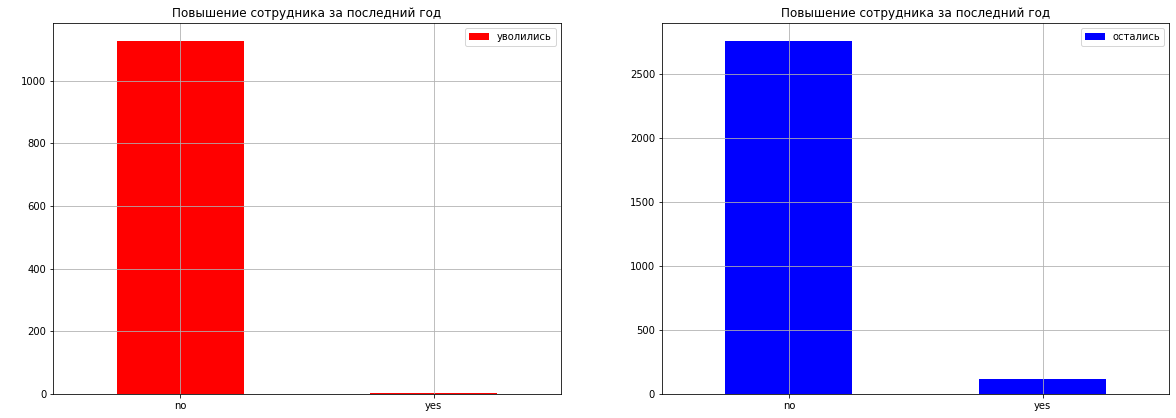

no     1127
yes       1
Name: last_year_promo, dtype: int64
no     2760
yes     112
Name: last_year_promo, dtype: int64


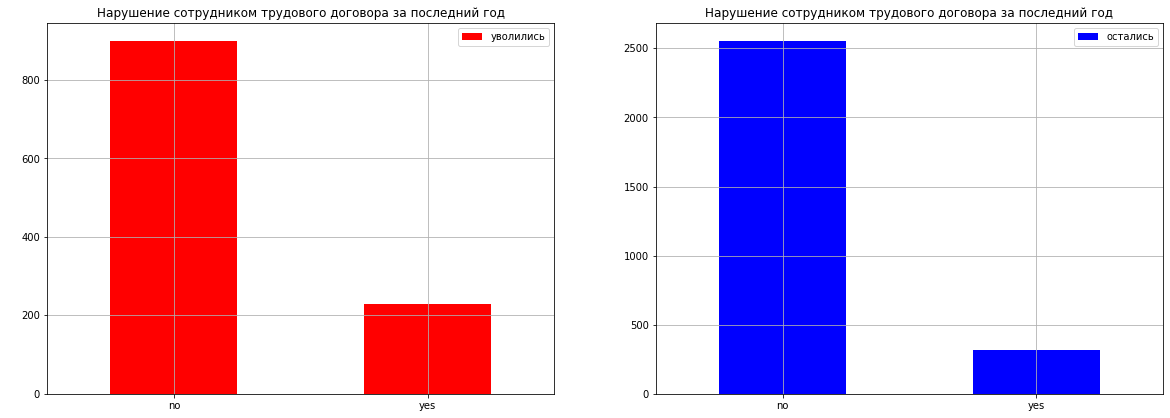

no     900
yes    228
Name: last_year_violations, dtype: int64
no     2555
yes     317
Name: last_year_violations, dtype: int64


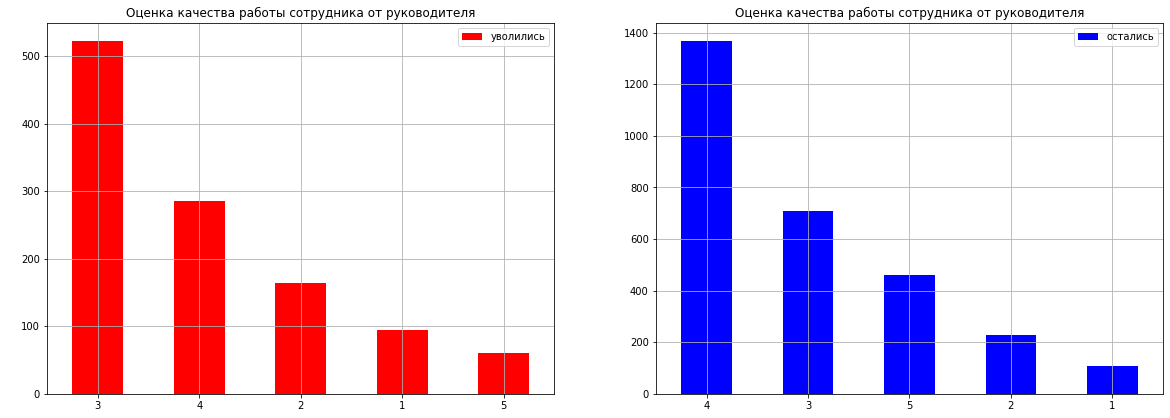

3    523
4    286
2    164
1     95
5     60
Name: supervisor_evaluation, dtype: int64
4    1368
3     710
5     460
2     227
1     107
Name: supervisor_evaluation, dtype: int64


In [111]:
dataframe_bar_diagram(fired_workers, contin_workers, fired_workers.drop(columns = ['id','salary','quit']).columns, cat_list)

Выведем также диаграмму с зарплатами уволенных сотрудников:

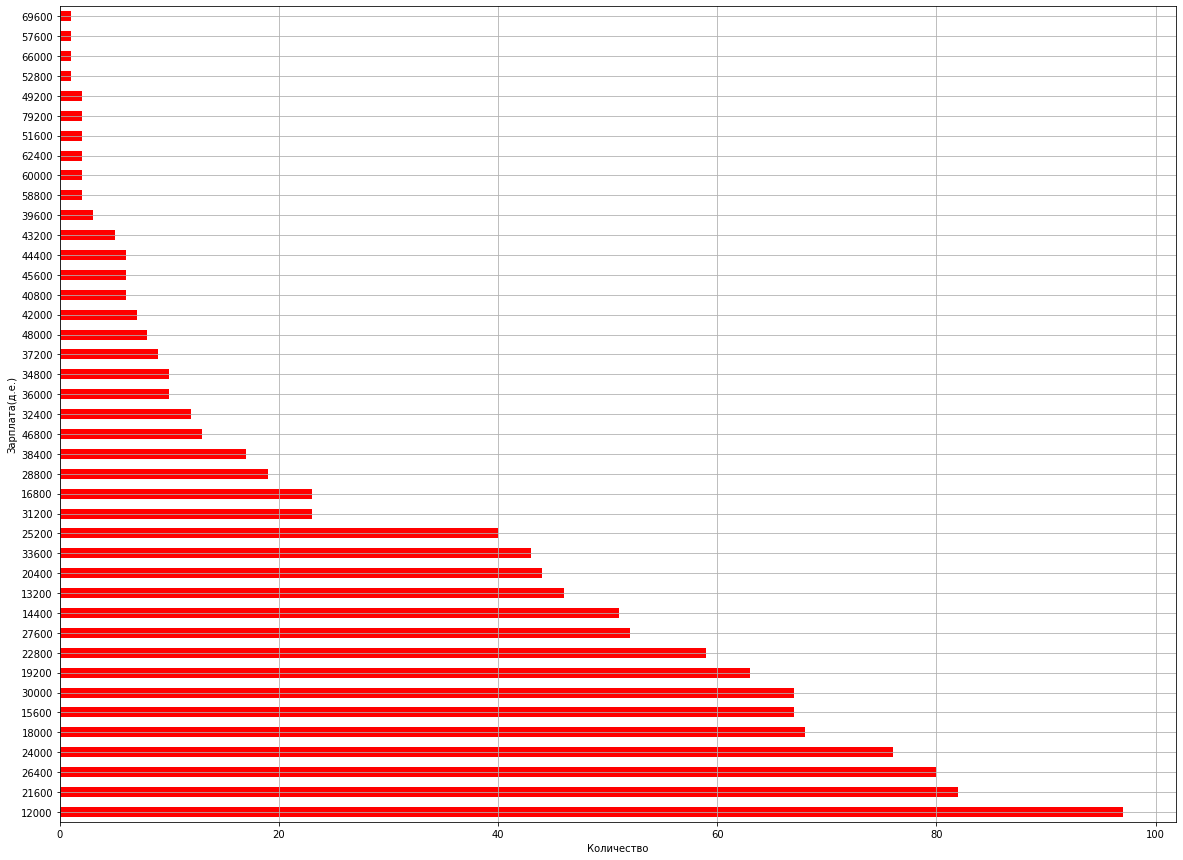

In [112]:
plt.figure(figsize=(20, 15))
# Вывод графиков гистограммы
fired_workers['salary'].value_counts().plot(kind='barh',  grid=True, color='red')
plt.xlabel('Количество')
plt.ylabel('Зарплата(д.е.)')
plt.show()

In [113]:
# Количество сотрудников с зарплатой менее 15000 д.е.
fired_workers.query('(salary <= 15000)')['level'].value_counts()

junior    194
Name: level, dtype: int64

**Портрет уволившегося сотрудника:**

Исходя из проведенного анализа данных, можно составить следующее описание уволившегося сотрудника:
- занимается деятельностью в отделе `sales`(отдел продаж)
- работает в должности `junior`
- имеется *низкая* или *средняя* загруженность 
- работает *менее года* или *год*
- имеет оценку качества работы от руководителя - `3`
- зарплата менее `15000` д.е.

Можно предположить, что такая текучка кадров возможна из-за: самого отдела, так как в отделе продаж мало кто остается надолго, и зарплатой, которая слишком мала для сотрудника, который хочет подольше остаться в компании.

#### Влияние уровня удовлетворённости сотрудника работой в компании на его увольнение

Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверим это утверждение: визуализируем и сравним распределения признака `job_satisfaction_rate` для ушедших и оставшихся сотрудников.

Объединим имеющиеся у нас данные с целевыми признаками:

In [114]:
full_test_data = full_select.merge(y_test_2, on='id', how='inner')

Выделим датасет с необходимыми нам данными: 

In [115]:
depend_satisf_quit = full_test_data[['id', 'job_satisfaction_rate', 'quit']]

Построим гистограммы и посмотрим на распределения данных для уволившихся и оставшихся сотрудников:

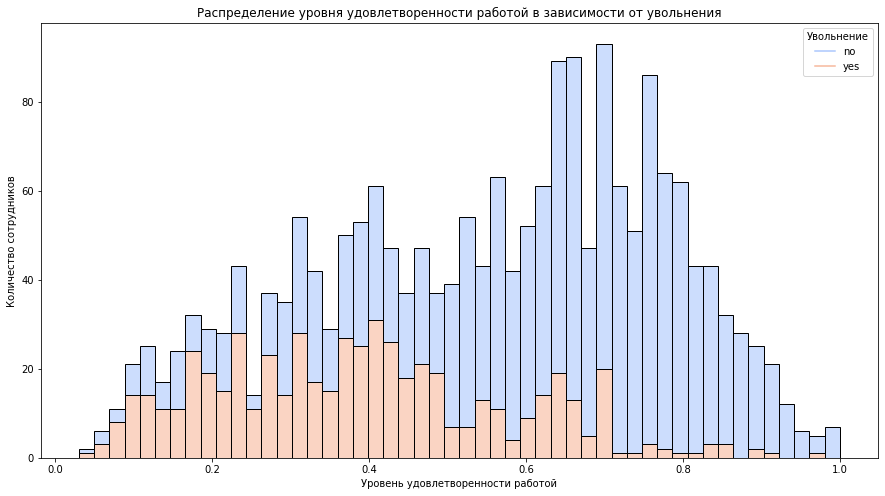

In [116]:
plt.figure(figsize=(15, 8))
# Построение гистограммы
sns.histplot(data=depend_satisf_quit, x='job_satisfaction_rate', hue='quit', palette='coolwarm', multiple="stack", bins=50, kde=False, alpha=0.6)

# Построение линии
sns.lineplot(data=depend_satisf_quit, x='job_satisfaction_rate', hue='quit', palette='coolwarm', estimator=None, lw=2)

plt.title('Распределение уровня удовлетворенности работой в зависимости от увольнения')
plt.xlabel('Уровень удовлетворенности работой')
plt.ylabel('Количество сотрудников')
plt.legend(title='Увольнение')
plt.show()

Из построенных гистограмм видно сильное смещение друг от друга.

Найдем средний уровень удовлетворённости на работе для обеих групп сотрудников и оценим их:

In [117]:
print('Средний уровень удовлетворённости на работе среди оставшихся сотрудников:', 
      round(depend_satisf_quit.query('quit == "no"')['job_satisfaction_rate'].mean(),3))

Средний уровень удовлетворённости на работе среди оставшихся сотрудников: 0.612


In [118]:
print('Средний уровень удовлетворённости на работе среди уволившихся сотрудников:', 
      round(depend_satisf_quit.query('quit == "yes"')['job_satisfaction_rate'].mean(),3))

Средний уровень удовлетворённости на работе среди уволившихся сотрудников: 0.388


Из визуализированного графика и посчитанных средних уровней удовлетворенности, можно говорить, что аналитики **правы**, так как уровень удовлетворённости на работе **влияет** на увольнение сотрудника из компании или продолжении работы в ней; средние уровни удовлетворённости сотрудников на работе отличаются почти в 2 раза (уволившиеся - 0.388, оставшихся - 0.612).

### Добавление нового входного признака

Допустим, `job_satisfaction_rate` и `quit` действительно связан, поэтому добавим `job_satisfaction_rate`, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.


Предскажем признак `job_satisfaction_rate` для тестовых данных с помощью лучшей модели из первой задачи:

In [119]:
pred_j_s_r = randomized_search.best_estimator_.predict(X_test_2)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


Добавим полученный предсказанный признак `job_satisfaction_rate` в датафрейм `full_test_data` в новый столбец `'pred_job_satisfaction_rate'`:

In [120]:
full_test_data['pred_job_satisfaction_rate'] = pred_j_s_r

Выведем первые строки получившегося датафрейма:

In [121]:
full_test_data.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit,pred_job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79,no,0.844857
1,686555,hr,junior,medium,1,no,no,4,30000,0.72,no,0.659786
2,467458,sales,middle,low,5,no,no,4,19200,0.64,no,0.662854
3,418655,sales,middle,low,6,no,no,4,19200,0.60,no,0.661092
4,789145,hr,middle,medium,5,no,no,5,40800,0.75,no,0.809972


Добавление нового признака было успешно выполнено.

### Подготовка данных

Подготовим признаки так же, как и в первой задаче: выполним подготовку в пайплайне, дополнив пайплайн предобработки. При кодировании будем учитывать особенности признаков и моделей.

In [122]:
# Создание экземпляра LabelEncoder
label_encoder = LabelEncoder()

In [123]:
# (1 - уволился, 0 - остался)
# кодирование признака quit в тренировочных данных
train_select_2['coded_quit'] = label_encoder.fit_transform(train_select_2['quit'])

# кодирование признака quit в тестовых данных
full_test_data['coded_quit'] = label_encoder.transform(full_test_data['quit'])

In [124]:
# инвертирование значений
train_select_2['coded_quit'] = 1 - train_select_2['coded_quit']
full_test_data['coded_quit'] = 1 - full_test_data['coded_quit']

Объединим тренировочные данные из первой задачи со второй:

In [125]:
train_select_2.merge(train_select[['id','job_satisfaction_rate']], on='id', how='inner')

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,coded_quit,job_satisfaction_rate


Из результата объединения видно, что похожих `id` в данных нет.

В связи с этим предскажем с помощью полученной лучшей модели из первой задачи для тренировочных данных:

In [126]:
pred_job_satisfaction_rate_2 = randomized_search.best_estimator_.predict(train_select_2.drop(columns=['id','quit', 'coded_quit'], axis=1))

/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


Добавим получившиеся результаты в тренировочный датафрейм `train_select_2` в новый столбец `'pred_job_satisfaction_rate'`:

In [127]:
train_select_2['pred_job_satisfaction_rate'] = pred_job_satisfaction_rate_2

Проверим запись данных:

In [128]:
train_select_2.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,coded_quit,pred_job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,1,0.661447
1,814010,sales,junior,medium,2,no,no,4,27600,no,1,0.835330
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,1,0.378997
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0,0.345536
4,910140,marketing,junior,medium,2,no,no,5,25200,no,1,0.721858


Теперь столбец `'id'` в `train_select_2` преобразуем в индекс и снова проверим на наличие дубликатов данные переда разбитием их на входной и целевой признаки тренировочных данных:

In [129]:
train_select_2 = train_select_2.set_index('id')

In [130]:
train_select_2.shape

(4000, 11)

In [131]:
train_select_2.duplicated().sum()

1413

Как видно из повторной проверки есть дубликаты, в связи с этим удалим их: 

In [132]:
train_select_2 = train_select_2.drop_duplicates(keep='first').reset_index(drop=False)

Проверим удаление:

In [133]:
train_select_2.shape

(2587, 12)

Удаление дубликатов прошло успешно.

Теперь можно начать деление на входные и целевые признаки тренировочных и тестовых данных соответственно:

In [134]:
X_train_2 = train_select_2.drop(columns=['id','quit', 'coded_quit'], axis=1)
y_train_2 = train_select_2['coded_quit']
X_test_2 = full_test_data.drop(columns=['id','job_satisfaction_rate', 'quit', 'coded_quit'], axis=1)
y_test_2 = full_test_data['coded_quit']

Проверим размеры признаков:

In [135]:
display(X_train_2.shape)
display(y_train_2.shape)
display(X_test_2.shape)
display(y_test_2.shape)

(2587, 9)

(2587,)

(2000, 9)

(2000,)

Данные готовы для обучения моделей.

Пайплайны для подготовки данных останутся теми же, что и в первой задаче, изменится только список с числовыми столбцами. 

In [136]:
# создаём списки с названиями признаков
num_columns_2 = ['employment_years', 'supervisor_evaluation', 'salary','pred_job_satisfaction_rate']

Создадим измененные пайплайны для подготовки признаков:

In [137]:
# создаём общий пайплайн для подготовки данных
data_preprocessor_2 = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', StandardScaler(), num_columns_2)
    ], 
    remainder='passthrough'
)

In [138]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final_2 = Pipeline([
    ('preprocessor', data_preprocessor_2),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

**Промежуточный вывод:**

В результате подготовки данных были выполнены следующие шаги:
- закодировали целевой признак `quit`
- предсказали признак `pred_job_satisfaction_rate` для тренировочных данных
- проверили размеры данных(строки, столбцы)
- провели разделение на входные и целевые признаки для тренировочных и тестовых данных
- создали изменеенные пайплайны для подготовки признаков

### Обучение моделей

Обучим как минимум три модели. Как минимум для двух из них подберем гиперпараметры. Проверим качество лучшей модели.
Метрику оценки качества в этой задаче будем использовать ROC-AUC. Критерий успеха: ROC-AUC ≥ 0.91 на тестовой выборке. 

В качестве рассматриваемых моделей оставим те же, что и в первой задаче, только теперь они будут учитываться классификации:
- `DecisionTreeClassifier()`
- `KNeighborsClassifier()`
- `SVC()`
- `LogisticRegression()`
- `RandomForestClassifier()`
- `GradientBoostingClassifier()`

In [139]:
# Параметры для поиска
param_grid_2 = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 15),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    
    # словарь для модели KNeighborsClassifier()
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    
    # словарь для модели SVC()
    {
        'models': [SVC(probability=True, random_state=RANDOM_STATE)],
        'models__kernel': ['rbf', 'sigmoid', 'poly'],
        'models__C': [0.1, 1, 10],
        'models__gamma': [0.1, 1, 10],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    
    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    
    # словарь для модели RandomForestClassifier()
    {
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [10, 50, 100],
        'models__max_depth': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    
    # словарь для модели GradientBoostingClassifier()
    {
        'models': [GradientBoostingClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [10, 50, 100],
        'models__learning_rate': [0.01, 0.1, 1.0],
        'models__max_depth': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

In [140]:
# Создаем пустые списки для таблицы результатов 
models_2 = []
roc_auc_train_result = []

С помощью цикла *for*, как и первой задачи, будем перебирать каждую модель из `param_grid_2`, обучать на тренировочных данных, предсказывать результат на тестовых данных, находить метрику ROC-AUC, выводить полученные результаты по рассмотренной модели и сохранять их для дальнейшего анализа. Также инициализируем класс `RandomizedSearchCV()` для для случайного поиска гиперпараметров с учётом ранее созданных параметров и пайплайнов:

In [141]:
for grid in param_grid_2:
    research = RandomizedSearchCV(
        pipe_final_2,
        grid,
        n_jobs=-1,
        cv=5,
        n_iter=5,
        scoring='roc_auc',
        random_state=RANDOM_STATE
    )

    # обучение модели
    research.fit(X_train_2, y_train_2)
    research_best_model_2 = research.best_estimator_['models']
    
    print(research_best_model_2)
    print('ROC-AUC рассмотренной модели на кросс-валидации:', research.best_score_, '\n\n')

    # сохранение результата рассмотренной модели
    models_2.append(research_best_model_2)
    roc_auc_train_result.append(research.best_score_)

DecisionTreeClassifier(max_depth=4, max_features=5, random_state=42)
ROC-AUC рассмотренной модели на кросс-валидации: 0.8980301437341695 


KNeighborsClassifier(n_neighbors=8)
ROC-AUC рассмотренной модели на кросс-валидации: 0.8962414153947853 


SVC(C=0.1, gamma=0.1, probability=True, random_state=42)
ROC-AUC рассмотренной модели на кросс-валидации: 0.8970667496140077 




/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
 

LogisticRegression(max_iter=1000, random_state=42)
ROC-AUC рассмотренной модели на кросс-валидации: 0.9034117510709008 


RandomForestClassifier(max_depth=5, n_estimators=10, random_state=42)
ROC-AUC рассмотренной модели на кросс-валидации: 0.917142591855033 


GradientBoostingClassifier(learning_rate=0.01, random_state=42)
ROC-AUC рассмотренной модели на кросс-валидации: 0.9127687088616806 




In [142]:
# данные об исследованных моделей
datatable_2 = {
    'model': models_2,
    'roc_auc_train_result': roc_auc_train_result,
}

In [143]:
result_table_2 = pd.DataFrame(datatable_2)
result_table_2.sort_values(by='roc_auc_train_result', ascending=False).reset_index(drop=True)

,model,roc_auc_train_result
0,"(DecisionTreeClassifier(max_depth=5, max_featu...",0.917143
1,([DecisionTreeRegressor(criterion='friedman_ms...,0.912769
2,"LogisticRegression(max_iter=1000, random_state...",0.903412
3,"DecisionTreeClassifier(max_depth=4, max_featur...",0.898030
4,"SVC(C=0.1, gamma=0.1, probability=True, random...",0.897067
5,KNeighborsClassifier(n_neighbors=8),0.896241


Из проведенного исследования на качество метрики ROC-AUC у выбранных моделей, условию - метрика должна быть больше или равна 91 - удовлетворяют следующие модели с гиперпараметрами:
- RandomForestClassifier(max_depth=8, random_state=42): roc_auc_test_result = 0.917143
- GradientBoostingClassifier(learning_rate=0.01, random_state=42): roc_auc_test_result = 0.912769

Из представленных результатов можно говорить, что модель `RandomForestClassifier()` показала себя лучше всего с результатом ROC-AUC 91.71% - это очень хороший показатель для модели.

Повторно проведем исследование моделей, но уже не всех и применим для тестовой выборки:

In [144]:
# Параметры для поиска
param_grid_3 = [
    
        # словарь для модели RandomForestClassifier()
    {
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [10, 50, 100],
        'models__max_depth': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }

]

In [145]:
randomized_search_2 = RandomizedSearchCV(
    pipe_final_2,
    param_grid_3,
    n_jobs=-1,
    n_iter=25,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE
)

# обучение модели
randomized_search_2.fit(X_train_2, y_train_2)
    
# предсказание модели на тестовых данных
pred_test_2 = randomized_search_2.best_estimator_.predict(X_test_2)
pred_proba_test_2 = randomized_search_2.best_estimator_.predict_proba(X_test_2)[:, 1]
roc_auc = roc_auc_score(y_test_2, pred_proba_test_2)

print('Лучшая модель и её параметры:\n\n', randomized_search_2.best_estimator_)
print('ROC-AUC лучшей рассмотренной модели на кросс-валидации:', research.best_score_)
print('ROC-AUC на тестовой выборке:', {roc_auc}, '\n\n')


Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                            

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


**Оценим важность признаков для лучшей модели**

Сохраним в `random_best_model_2` лучшую модель, которая была найдена: 

In [146]:
# лучшая модель 
random_best_model_2 = randomized_search_2.best_estimator_.named_steps['models']

# preprocessor лучшей модели
preprocessor_best_model_2 = randomized_search_2.best_estimator_['preprocessor']

In [147]:
# подготовка данных с помощью preprocessor_best_model
X_train_preproc_2 = preprocessor_best_model_2.transform(X_train_2)
X_test_preproc_2 = preprocessor_best_model_2.transform(X_test_2)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [148]:
# получение имен признаков после препроцессинга
ohe_columns_bm = preprocessor_best_model_2.named_transformers_['ohe'].get_feature_names_out(input_features=ohe_columns)
ord_columns_bm = preprocessor_best_model_2.named_transformers_['ord'].get_feature_names_out(input_features=ord_columns)
num_columns_bm_2 = preprocessor_best_model_2['num'].get_feature_names_out(input_features=num_columns_2)
columns_name_list_2 = preprocessor_best_model_2.get_feature_names_out()

In [149]:
# создание DataFrame с трансформированными данными
X_train_preproc_2 = pd.DataFrame(X_train_preproc_2, columns=columns_name_list_2)
X_test_preproc_2 = pd.DataFrame(X_test_preproc_2, columns=columns_name_list_2)

In [150]:
# обучение лучшей модели
random_best_model_2.fit(X_train_preproc_2, y_train_2)

RandomForestClassifier(max_depth=6, n_estimators=50, random_state=42)

In [151]:
explainer_2 = shap.Explainer(random_best_model_2.predict, X_train_preproc_2)
shap_values_2 = explainer_2(X_test_preproc_2)

PermutationExplainer explainer: 2001it [07:38,  4.27it/s]                          


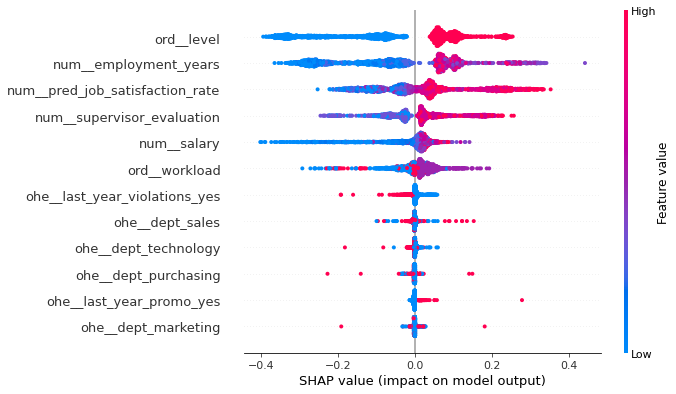

In [152]:
# Построение графика с именами признаков
shap.plots.beeswarm(shap_values_2, max_display=21)

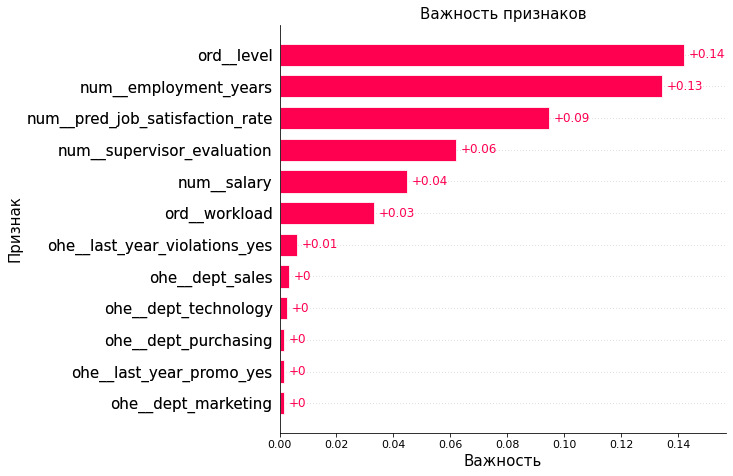

In [153]:
shap.plots.bar(shap_values_2, max_display=21, show=False)
plt.yticks(fontsize=15)
plt.xlabel('Важность', fontsize=15)
plt.ylabel('Признак', fontsize=15)
plt.title('Важность признаков', fontsize=15);

Из результатов графика можно сказать следующее:
- признаки, расположенные в верхней части графика, имеют наибольшее влияние на предсказания модели, а в нижней части - меньшее влияние
- положительные значения указывают на то, что признак увеличивает предсказание модели, а отрицательные значения - признак уменьшает предсказание модели
- красные точки (высокие значения признаков) и синие точки (низкие значения признаков) показывают, как различные значения признаков влияют на предсказания

Из представленных графиков следует, что *наибольшее* влияние имеют признаки: `level`,  `employment_years`, `pred_job_satisfaction_rate`; а *наименьшее* - `dept` - отдел `purchasing`, `dept` - отдел `marketing`, `last_year_promo` - сотрудники у которых было повышение.

**Сделаем выводы о значимости признаков**

В результате оценки важности признаков были получены следующие результаты:
- наименее значимые признаки для модели были определены:
    - `dept`
    - `last_year_promo`
- наиболее значимые признаки для модели были определены:
    - `level`
    - `employment_years`
    - `pred_job_satisfaction_rate`
    
Признак `level` показывает, что низкий уровень должности может поспособствовать увольнению сотрудника. Признак `employment_years` указывает, что чем дольше сотрудник работает в компании, тем менее вероятно, что он уйдет, так как скорее он уже привык к сложившейся в ней атмосфере. Признак `pred_job_satisfaction_rate` говорит о том, что чем более удовлетворен сотрудник, тем меньше вероятность его увольнения.

Отдел, в котором работает сотрудник - `dept` - и повышение за последний год - `last_year_promo` - наименьше всего влияют, так как в каждом отделе свой устрой и повышений очень-очень мало, поэтому по этим показателям трудно говорить об удовлетворенности сотрудников.

### Выводы

Из проведенных исследований можно говорить о следующем:
- данные были разделены на одни и те же выборки
- для оценки моделей была выбрана метрика ROC-AUC
- для нахождения лучшей модели были выбраны следующие: 
    - `DecisionTreeClassifier()`
    - `KNeighborsClassifier()`
    - `SVC()`
    - `LogisticRegression()`
    - `RandomForestClassifier()`
    - `GradientBoostingClassifier()`
    
Из проведенных вычислений метрики ROC-AUC и переборе разных гипермараметров в моделях лучше всего справилась модель `RandomForestClassifier()` с гиперпараметрами `max_depth=8`,`random_state=42` и результатом метрики ROC-AUC равным `0.922356`, что удовлетворяет требованию и является максимальным из всех рассмотренных моделей. После повторного изучения уже данного метода в отдельности результат остался тем же.

Согласно изученной информации из Интернета, была выбрана модель `RandomForestClassifier()` - модель, реализующая метод случайного леса для задач классификации, является ансамблевым методом, который объединяет множество деревьев решений для улучшения точности и устойчивости модели. Данный метод чаще лучше справляется с задачами классификации благодаря способности уменьшать переобучение, учитывать сложные взаимодействия между признаками, быть устойчивым к выбросам и гибко настраиваться.

## Общий вывод

Сформулируем общий вывод из проведенного нами исследования:

**Задача 1. Предсказание уровня удовлетворённости сотрудника**

- Загрузка данных:
    - считали CSV-файлы 
- Предобработка данных:
    - изучили основную информацию о датафреймах
    - определили, что типы данных соответствуют действительности
    - определили, что названия столбцов имеют правильную запись
    - обработали пропуски в столбцах датафреймов с помощью созданного пайплайна
    - проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
    - преобразовали неявные дубликаты там, где это было возможно
- Исследовательский анализ данных:
    - В результате исследования количественных признаков были получены следующие результаты:
        - были проанализированы выбросы во всех датафреймах
        - было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, а у некоторых крайне мало выбросов, что маловероятно повлияет на результаты исследования

    - В результате исследования категориальных признаков были получены следующие результаты:
        - наиболее загружены отделы продаж (`sales`) и технологий (`technology`)
        - сеньоры в компании составляют около 9%, мидлы - примерно 44%, джуны - около 47%
        - чуть более 50% работников имеют средний уровень загруженности, 30% - низкий, 18% - высокий 
        - только 3% сотрудников компании *повысили* за прошлый год, остальные 97% остались в той же должности
        - 86% сотрудников *не нарушали* трудовой договор за последний год

    - В результате исследования корреляционного анализа были получены следующие результаты:
        - построили тепловую карту матрицы корреляционных значений и проанализировали 
        - сделали выводы о взаимосвязи признаков
        - проанализировали и определили, что между признаками нет мультиколлениарности
- Подготовка данных:
    - проверили размеры данных(строки, столбцы)
    - провели разделение на входные и целевые признаки для тренировочных и тестовых данных
    - создали пайплайны для подготовки признаков
- Обучение моделей:

Из проведенных вычислений метрики SMAPE и переборе разных гипермараметров в моделях лучше всего справилась модель `GradientBoostingRegressor()` с гиперпараметрами `max_depth=9`, `n_estimators=50`, `random_state=42` и результатом метрики SMAPE на кросс-валидации `13.342820`, что удовлетворяет требованию и является минимальным из всех рассмотренных моделей. После повторного изучения уже данного метода в отдельности результат метрики SMAPE на тестовой выборке удалось получить `11.138166` и моделью `GradientBoostingRegressor()` с гиперпараметрами `max_depth=7`, `random_state=42`.

В результате оценки важности признаков были получены следующие результаты:
- наименее значимые признаки для модели были определены:
    - `dept`
    - `last_year_promo`
- наиболее значимые признаки для модели были определены:
    - `supervisor_evaluation`
    - `level`
    - `salary`
    - `employment_years`
    - `workload`
    
Признак `supervisor_evaluation` говорит о том, что чем выше оценки руководителя, тем выше увеличивают предсказанный уровень удовлетворенности. Признак `level` показывает, что низкий уровень должности может снижать уровень удовлетворенности. Признак `salary` показывает, что чем выше зарплата, тем удовлетворенее сотрудник (с этим нельзя не согласиться). Признак `employment_years` указывает, что чем дольше сотрудник работает в компании, тем более он удовлетворен, так как скорее он уже привык к сложившейся в ней атмосфере. Признак `workload` говорит о том, что чем выше нагрузка на сотрудника, тем он менее он удовлетворен, так как пытается решить все задачи, которые ему дали и находится в стрессовых условиях. 


**Задача 2: Предсказание увольнения сотрудника из компании**

- Загрузка данных:
    - считали CSV-файлы 
- Предобработка данных:
    - изучили основную информацию о датафреймах
    - определили, что типы данных соответствуют действительности
    - определили, что названия столбцов имеют правильную запись
    - проверили данные на наличие пропусков
    - проверили и проанализировали данные на наличие дубликатов как явных, так и неявных
    - преобразовали неявные дубликаты там, где это было возможно
- Исследовательский анализ данных:
    - В результате исследования количественных признаков были получены следующие результаты:
        - были проанализированы выбросы во всех датафреймах
        - было проведено исследование на удаление или сохранение выбросов в результате которого было принято решение **не удалять** выбросы, так как не все графики имеют нормальное распределение, а у некоторых крайне мало выбросов, что маловероятно повлияет на результаты исследования
    - В результате исследования категориальных признаков были получены следующие результаты:
        - наиболее загружены отделы продаж (`sales`) и технологий (`technology`)
        - сеньоры в компании составляют около 9%, мидлы - примерно 42%, джуны - около 49%
        - чуть более 50% работников имеют средний уровень загруженности, 30% - низкий, около 17% - высокий 
        - менее 3% сотрудников компании *повысили* за прошлый год, остальные же остались в той же должности
        - 86% сотрудников *не нарушали* трудовой договор за последний год
        - около 28% сотрудников уволились из комппании
    - В результате исследования корреляционного анализа были получены следующие результаты:
        - построили тепловую карту матрицы корреляционных значений и проанализировали 
        - сделали выводы о взаимосвязи признаков
        - проанализировали и определили, что между признаками нет мультиколлениарности
    - составили **портрет уволившегося сотрудника:**
        - занимается деятельностью в отделе `sales`(отдел продаж)
        - работает в должности `junior`
        - имеется *низкая* или *средняя* загруженность 
        - работает *менее года* или *год*
        - имеет оценку качества работы от руководителя - `3`
        - зарплата менее `15000` д.е.
    - определили, что уровень удовлетворённости на работе **влияет** на увольнение сотрудника из компании или продолжение работы в ней; средние уровни удовлетворённости сотрудников на работе отличаются почти в 2 раза (уволившиеся - 0.388, оставшихся - 0.612)
- добавили новый входной признак `job_satisfaction_rate` для тестовых данных с помощью лучшей модели из первой задачи
- Подготовка данных:
    - закодировали целевой признак `quit`
    - предсказали признак `pred_job_satisfaction_rate` для тренировочных данных
    - проверили размеры данных(строки, столбцы)
    - провели разделение на входные и целевые признаки для тренировочных и тестовых данных
    - создали изменеенные пайплайны для подготовки признаков
- Обучение моделей:

Из проведенных вычислений метрики ROC-AUC и переборе разных гипермараметров в моделях лучше всего справилась модель `RandomForestClassifier()` с гиперпараметрами `max_depth=8`,`random_state=42` и результатом метрики ROC-AUC равным `0.922356`, что удовлетворяет требованию и является максимальным из всех рассмотренных моделей. После повторного изучения уже данного метода в отдельности результат остался тем же.

В результате оценки важности признаков были получены следующие результаты:
- наименее значимые признаки для модели были определены:
    - `dept`
    - `last_year_promo`
- наиболее значимые признаки для модели были определены:
    - `level`
    - `employment_years`
    - `pred_job_satisfaction_rate`
    
Признак `level` показывает, что низкий уровень должности может поспособствовать увольнению сотрудника. Признак `employment_years` указывает, что чем дольше сотрудник работает в компании, тем менее вероятно, что он уйдет, так как скорее он уже привык к сложившейся в ней атмосфере. Признак `pred_job_satisfaction_rate` говорит о том, что чем более удовлетворен сотрудник, тем меньше вероятность его увольнения.


**Предложения для бизнеса**

Исходя из всех выше изложенных выводов, для моделировании и принятии бизнес-решений можно порекомендовать:
1. Попытаться создать какие-то условия, чтобы сотрудника удержать, и прератить брать на работу "бегунков", которые меняют место работы каждые 3-4 месяца.
2. Рассмотреть возможное повышение сотрудников, после определенного времени работы, так как процент повышений в компании **критически мал**.
3. Обращать внимание на то, заинтересован ли сотрудник в работе, в тот ли отдел он попал; необходимо сделать так, чтобы сотрудник понял, что задача, которую ему поставят может быть интересной с определенной точки зрения. Именно заинтересованность сотрудника и влияет на то - уйдет он в ближайшем будущем из компании или останется. 
4. Рассмотреть установление такой минимальной зарплаты, при которой сотрудник не хотел бы сразу "сбегать" из компании через малое время работы в ней.  
5. Постараться распределять нагрузку на отделы и их работников *равномерно*, так как если задач нет или наоборот их слишком много, то сотрудник может просто-напросто выгореть и перестать хотеть тянуть все в одиночку, а это может поспособствовать решению об уходе из компании.